In [1]:
import pandas as pd

In [2]:
train_df=pd.read_csv("data/raw/train.csv")
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 196.8 MB


In [3]:
train_df.shape

(3000888, 6)

In [4]:
train_df['date'] = pd.to_datetime(train_df['date'], format="%Y-%m-%d")



In [5]:
transactions_df=pd.read_csv("data/raw/transactions.csv")

In [6]:
holidays_df=pd.read_csv("data/raw/holidays_events.csv")



In [7]:
holidays_df['date'] = pd.to_datetime(holidays_df['date'], format="%Y-%m-%d")

In [8]:
stores_df=pd.read_csv("data/raw/stores.csv")
oil_df=pd.read_csv("data/raw/oil.csv")


In [9]:
oil_df['date'] = pd.to_datetime(oil_df['date'], format="%Y-%m-%d")

In [10]:
transactions_df['date'] = pd.to_datetime(transactions_df['date'], format="%Y-%m-%d")

In [11]:
df = train_df.merge(
    stores_df,
    on="store_nbr",
    how="left"
)

In [12]:
train_df.shape

(3000888, 6)

In [13]:
transactions_df['date'] = pd.to_datetime(transactions_df['date'], format="%Y-%m-%d")

In [14]:
import pandas as pd

# ============================================================
# 1. Clean up duplicate rows and leftover columns in df
# ============================================================
# If df has duplicates from the previous run, restore original rows
if df.duplicated(subset=["id"]).any():
    df = df.drop_duplicates(subset=["id"]).copy()

# Drop any leftover holiday columns from the previous run
cols_to_drop = [c for c in df.columns if 'Holiday' in c or 'Event' in c]
if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)

# ============================================================
# 2. Filter holidays
# ============================================================
holidays = holidays_df[
    (~holidays_df["transferred"]) & 
    (holidays_df["type"] != "Work Day")
].copy()

holidays["is_Holiday"] = holidays["type"].isin(["Holiday", "Additional", "Bridge"]).astype(int)
holidays["is_Event"] = (holidays["type"] == "Event").astype(int)

# ============================================================
# 3. Split and aggregate (prevents duplicate matches)
# ============================================================
national = holidays[holidays["locale"] == "National"].groupby("date")[["is_Holiday", "is_Event"]].max().reset_index()

regional = holidays[holidays["locale"] == "Regional"].rename(columns={"locale_name": "state"})
regional = regional.groupby(["date", "state"])[["is_Holiday", "is_Event"]].max().reset_index()

local = holidays[holidays["locale"] == "Local"].rename(columns={"locale_name": "city"})
local = local.groupby(["date", "city"])[["is_Holiday", "is_Event"]].max().reset_index()

# ============================================================
# 4. Use a temporary DataFrame for merges to keep df clean
# ============================================================
temp = df[["date", "state", "city"]].copy()

# Merge National
temp = temp.merge(national, on="date", how="left")
temp.rename(columns={"is_Holiday": "nat_h", "is_Event": "nat_e"}, inplace=True)

# Merge Regional
temp = temp.merge(regional, on=["date", "state"], how="left")
temp.rename(columns={"is_Holiday": "reg_h", "is_Event": "reg_e"}, inplace=True)

# Merge Local
temp = temp.merge(local, on=["date", "city"], how="left")
temp.rename(columns={"is_Holiday": "loc_h", "is_Event": "loc_e"}, inplace=True)

# Fill NaNs with 0
temp_cols = ["nat_h", "nat_e", "reg_h", "reg_e", "loc_h", "loc_e"]
temp[temp_cols] = temp[temp_cols].fillna(0).astype(int)

# ============================================================
# 5. Assign the final 2 columns back to original df
# ============================================================
df["is_Holiday"] = temp[["nat_h", "reg_h", "loc_h"]].max(axis=1)
df["is_Event"] = temp[["nat_e", "reg_e", "loc_e"]].max(axis=1)

In [15]:
df.shape

(3000888, 12)

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\rohet\AppData\Local\Temp\ipykernel_16040\1882329169.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=df, x='is_Holiday', y='sales', ci=95)


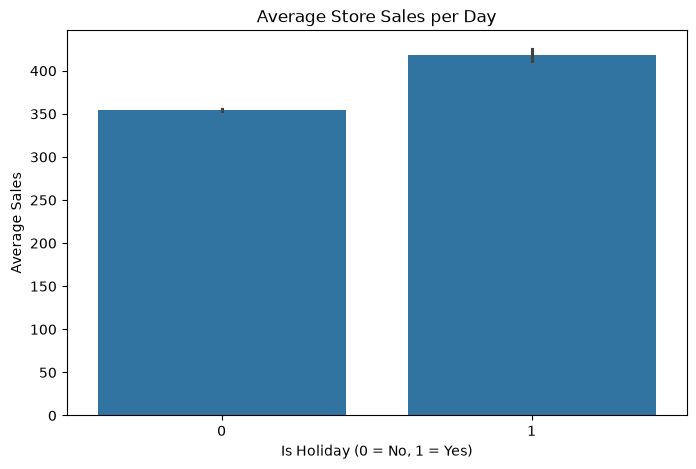

In [17]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='is_Holiday', y='sales', ci=95)
plt.title('Average Store Sales per Day')
plt.xlabel('Is Holiday (0 = No, 1 = Yes)')
plt.ylabel('Average Sales')
plt.show()

In [18]:
oil_df.isnull().sum()

date           0
dcoilwtico    43
dtype: int64

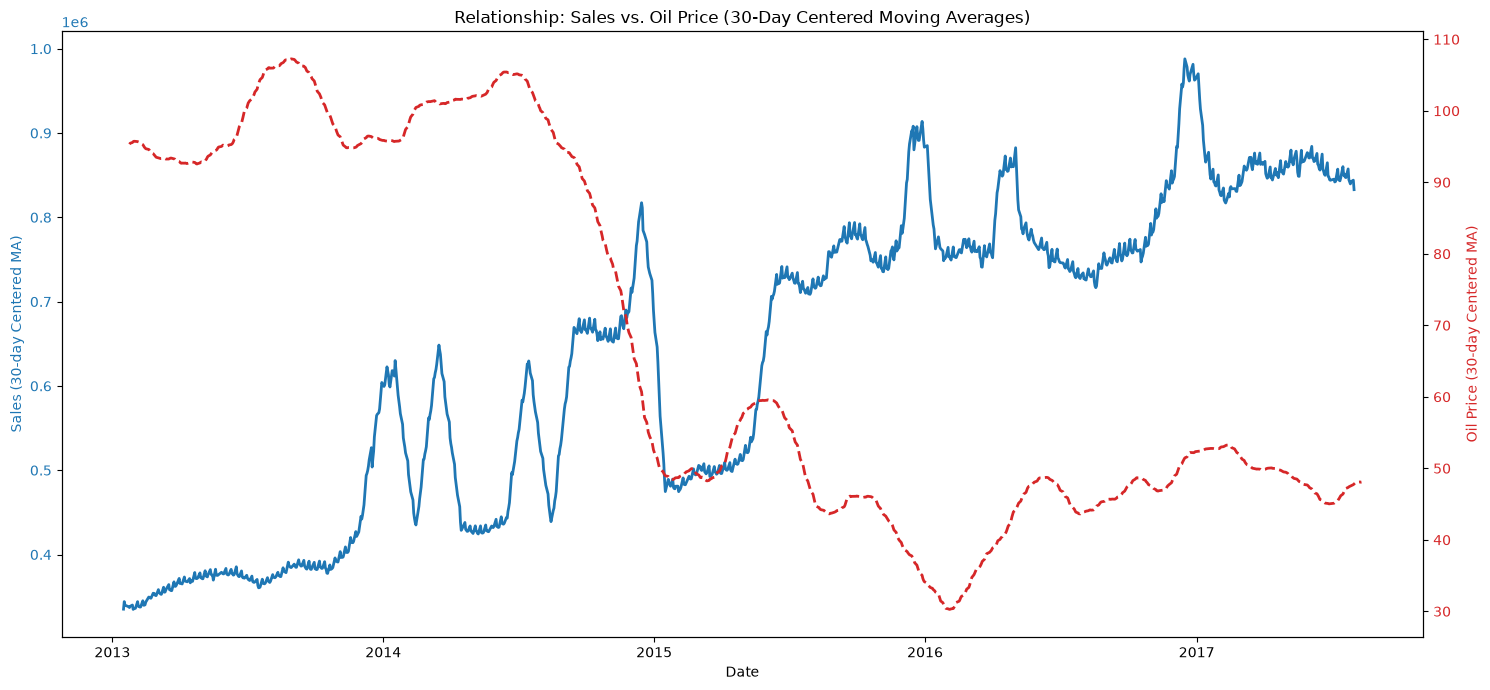

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Make a copy of oil_df and drop all rows with missing oil prices
oil_copy = oil_df.copy()
oil_copy = oil_copy.dropna(subset=["dcoilwtico"]).reset_index(drop=True)

# 2. Calculate the centered 30-day moving average on the available oil data
oil_copy["oil_ma"] = oil_copy["dcoilwtico"].rolling(window=30, center=True).mean()

# 3. Aggregate daily sales from df and calculate its centered 30-day moving average
daily_sales = df.groupby("date")["sales"].sum().reset_index()
daily_sales["sales_ma"] = daily_sales["sales"].rolling(window=30, center=True).mean()

# 4. Merge them on date (inner join to keep only dates where we have oil data)
merged_ma = pd.merge(daily_sales, oil_copy, on="date", how="inner")

# 5. Plot the relationship using a dual Y-axis
fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot Sales Moving Average (Left Axis)
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Sales (30-day Centered MA)', color=color)
ax1.plot(merged_ma['date'], merged_ma['sales_ma'], color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# Plot Oil Moving Average (Right Axis)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Oil Price (30-day Centered MA)', color=color)
ax2.plot(merged_ma['date'], merged_ma['oil_ma'], color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Relationship: Sales vs. Oil Price (30-Day Centered Moving Averages)')
fig.tight_layout()
plt.show()

In [20]:
df['date'].nunique()

1684

In [21]:
oil_df['date'].nunique()

1218

In [22]:
import numpy as np
import bisect

# 0. Drop the column first if it already exists from a previous run (for safety)
if "oil_price" in df.columns:
    df.drop(columns=["oil_price"], inplace=True)

# 1. Create a clean copy of oil_df dropping NaNs
known_oil = oil_df.dropna(subset=["dcoilwtico"]).sort_values("date").reset_index(drop=True)

# 2. Get sorted known dates and prices as lists for fast lookup
known_dates = known_oil["date"].tolist()
known_prices = known_oil["dcoilwtico"].tolist()
known_dict = dict(zip(known_dates, known_prices))

# 3. Iterate over unique dates in df to calculate filled values
unique_dates = sorted(df["date"].unique())
date_to_price = {}

for d in unique_dates:
    if d in known_dict:
        date_to_price[d] = known_dict[d]
    else:
        # Find insertion index in sorted known_dates
        idx = bisect.bisect_right(known_dates, d)
        
        # Get slice of up to 10 known values before the insertion point
        slice_before = known_prices[max(0, idx - 10) : idx]
        
        # Get slice of up to 10 known values after/starting from the insertion point
        slice_after = known_prices[idx : min(len(known_prices), idx + 10)]
        
        # Average the combined values
        date_to_price[d] = np.mean(slice_before + slice_after)

# 4. Map the calculated oil prices directly to df using the date
df["oil_price"] = df["date"].map(date_to_price)

In [23]:
df.shape

(3000888, 13)

In [24]:
# Replace 'col1' and 'col2' with your column names (e.g., 'date' and 'store_nbr')
unique_pairs_count = transactions_df.groupby(['date', 'store_nbr']).ngroups
print(unique_pairs_count)

83488


In [25]:
# Replace 'col1' and 'col2' with your column names (e.g., 'date' and 'store_nbr')
unique_pairs_count = df.groupby(['date', 'store_nbr']).ngroups
print(unique_pairs_count)

90936


In [26]:
# Sort by store_nbr first, and then by date
transactions_sorted = transactions_df.sort_values(by=['store_nbr', 'date']).reset_index(drop=True)

# Print the sorted dataframe to verify
print(transactions_sorted.head(10))

        date  store_nbr  transactions
0 2013-01-02          1          2111
1 2013-01-03          1          1833
2 2013-01-04          1          1863
3 2013-01-05          1          1509
4 2013-01-06          1           520
5 2013-01-07          1          1807
6 2013-01-08          1          1869
7 2013-01-09          1          1910
8 2013-01-10          1          1679
9 2013-01-11          1          1813


In [27]:
# Group by date and store, and sum the sales
daily_store_sales = df.groupby(['date', 'store_nbr'])['sales'].sum().reset_index()

# Rename the column to represent the total daily sales for that store
daily_store_sales.rename(columns={'sales': 'total_sales'}, inplace=True)

# Print the head of the new dataframe to verify
print("Compressed DataFrame Shape:", daily_store_sales.shape)
print(daily_store_sales.head())

Compressed DataFrame Shape: (90936, 3)
        date  store_nbr  total_sales
0 2013-01-01          1          0.0
1 2013-01-01          2          0.0
2 2013-01-01          3          0.0
3 2013-01-01          4          0.0
4 2013-01-01          5          0.0


In [28]:
import pandas as pd

# 1. Count the number of store-date pairs where total sales is exactly 0
zero_sales_df = daily_store_sales[daily_store_sales['total_sales'] == 0.0]
zero_sales_count = len(zero_sales_df)
print(f"1. Total store-date pairs with 0 sales: {zero_sales_count}")

# 2. Merge daily store sales with transactions to check the relationships
# We do a left merge to check all sales days
test_df = pd.merge(daily_store_sales, transactions_df, on=['date', 'store_nbr'], how='left')

# Test 1: Pairs with 0 sales must NOT have transaction records (i.e. transactions is NaN)
test1_exceptions = test_df[(test_df['total_sales'] == 0.0) & (test_df['transactions'].notnull())]
print(f"2. Exceptions to Test 1 (0 sales but has transaction record): {len(test1_exceptions)}")

# Test 2: Pairs with > 0 sales must have a transaction record (i.e. transactions is not NaN and > 0)
test2_exceptions = test_df[(test_df['total_sales'] > 0.0) & (test_df['transactions'].isnull())]
print(f"3. Exceptions to Test 2 (has sales but missing transaction record): {len(test2_exceptions)}")

# Optional: If there are exceptions, let's see a sample of them
if len(test1_exceptions) > 0:
    print("\nSample of exceptions to Test 1:")
    print(test1_exceptions.head())

if len(test2_exceptions) > 0:
    print("\nSample of exceptions to Test 2 (e.g. days where store has sales but no transaction row):")
    print(test2_exceptions.head())

1. Total store-date pairs with 0 sales: 7330
2. Exceptions to Test 1 (0 sales but has transaction record): 0
3. Exceptions to Test 2 (has sales but missing transaction record): 118

Sample of exceptions to Test 2 (e.g. days where store has sales but no transaction row):
            date  store_nbr  total_sales  transactions
9135  2013-06-19         10  3802.291998           NaN
9160  2013-06-19         35  1699.048000           NaN
9168  2013-06-19         43  4642.495001           NaN
9179  2013-06-19         54  2977.852000           NaN
19741 2014-01-02         32  3146.146702           NaN


In [29]:
# Print all 118 exceptions
with pd.option_context('display.max_rows', 150):
    print(test2_exceptions)

            date  store_nbr   total_sales  transactions
9135  2013-06-19         10   3802.291998           NaN
9160  2013-06-19         35   1699.048000           NaN
9168  2013-06-19         43   4642.495001           NaN
9179  2013-06-19         54   2977.852000           NaN
19741 2014-01-02         32   3146.146702           NaN
24108 2014-03-24         25   8014.160000           NaN
58992 2016-01-01         25  16433.394000           NaN
59022 2016-01-02          1   8877.175000           NaN
59024 2016-01-02          3  47348.572000           NaN
59025 2016-01-02          4  15849.819000           NaN
59026 2016-01-02          5  11846.418980           NaN
59027 2016-01-02          6  22800.991000           NaN
59028 2016-01-02          7  18703.899000           NaN
59029 2016-01-02          8  27211.342970           NaN
59030 2016-01-02          9  26489.769970           NaN
59031 2016-01-02         10   9838.171980           NaN
59032 2016-01-02         11  30280.388000       

In [30]:
import pandas as pd

# 1. Clean up any leftover transactions column in df from previous runs (if any)
if "transactions" in df.columns:
    df.drop(columns=["transactions"], inplace=True)

# 2. Group sales by date and store to get daily store sales
daily_sales = df.groupby(["date", "store_nbr"])["sales"].sum().reset_index()
daily_sales.rename(columns={"sales": "total_sales"}, inplace=True)

# 3. Merge daily sales with transactions_df (places NaNs on all missing/closed days)
daily_sales = daily_sales.merge(transactions_df, on=["date", "store_nbr"], how="left")

# 4. If total_sales is 0, transactions MUST be 0 (closed days)
# Otherwise, it keeps the value from transactions_df (or NaN if it was one of the 118 exceptions)
daily_sales.loc[daily_sales["total_sales"] == 0, "transactions"] = 0

# 5. Merge these transaction counts back into your main df
df = df.merge(daily_sales[["date", "store_nbr", "transactions"]], on=["date", "store_nbr"], how="left")

In [31]:
df.shape

(3000888, 14)

In [32]:
a=df.isnull().sum()
a

id                 0
date               0
store_nbr          0
family             0
sales              0
onpromotion        0
city               0
state              0
type               0
cluster            0
is_Holiday         0
is_Event           0
oil_price          0
transactions    3894
dtype: int64

In [33]:
import numpy as np

# 1. Fit a line (y = mx + c) for each store on days where transactions and sales > 0 are known
store_models = {}
for store_nbr in daily_sales["store_nbr"].unique():
    # Fit only on open days where transactions are recorded
    store_data = daily_sales[
        (daily_sales["store_nbr"] == store_nbr) & 
        (daily_sales["transactions"].notnull()) & 
        (daily_sales["total_sales"] > 0)
    ]
    
    x = store_data["total_sales"].values
    y = store_data["transactions"].values
    
    # Fit y = mx + c
    m, c = np.polyfit(x, y, 1)
    store_models[store_nbr] = (m, c)

# 2. Predict transactions for the 118 open days that are missing transactions (NaN)
nan_rows = daily_sales["transactions"].isnull()
predicted_vals = []

for idx, row in daily_sales[nan_rows].iterrows():
    store_nbr = row["store_nbr"]
    total_sales = row["total_sales"]
    m, c = store_models[store_nbr]
    
    # Estimate transactions using the store's fitted line
    pred_val = int(round(max(0, m * total_sales + c)))
    predicted_vals.append(pred_val)

# Update daily_sales with the predictions
daily_sales.loc[nan_rows, "transactions"] = predicted_vals
daily_sales["transactions"] = daily_sales["transactions"].astype(int)

# 3. Drop the temporary transactions column (containing NaNs) from df
if "transactions" in df.columns:
    df.drop(columns=["transactions"], inplace=True)

# 4. Merge the fully filled transactions column back into your main df
df = df.merge(daily_sales[["date", "store_nbr", "transactions"]], on=["date", "store_nbr"], how="left")

In [34]:
df.shape

(3000888, 14)

In [35]:
df.isnull().sum()

id              0
date            0
store_nbr       0
family          0
sales           0
onpromotion     0
city            0
state           0
type            0
cluster         0
is_Holiday      0
is_Event        0
oil_price       0
transactions    0
dtype: int64

In [36]:
# 1. Add Day of Week to daily store sales
daily_store_sales['day_of_week'] = daily_store_sales['date'].dt.day_name()

# 2. Print average sales by day of the week (ordered chronologically)
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
avg_sales_by_day = daily_store_sales.groupby('day_of_week')['total_sales'].mean().reindex(weekday_order)
print("--- Average Daily Sales per Store by Weekday ---")
print(avg_sales_by_day)

# 3. Prove that zero sales are due to store openings (e.g., Store 52)
# Find the first date Store 52 had sales > 0
store_52_data = daily_store_sales[daily_store_sales['store_nbr'] == 52]
first_active_date = store_52_data[store_52_data['total_sales'] > 0]['date'].min()
total_zero_days = len(store_52_data[store_52_data['total_sales'] == 0.0])

print(f"\n--- Store 52 Grand Opening Check ---")
print(f"First active sales date for Store 52: {first_active_date.strftime('%Y-%m-%d')}")
print(f"Total days with 0 sales before opening: {total_zero_days}")

--- Average Daily Sales per Store by Weekday ---
day_of_week
Monday       11435.976168
Tuesday      10554.186813
Wednesday    10986.010249
Thursday      9356.837058
Friday       10732.858539
Saturday     14300.103592
Sunday       15281.817066
Name: total_sales, dtype: float64

--- Store 52 Grand Opening Check ---
First active sales date for Store 52: 2017-04-20
Total days with 0 sales before opening: 1566


In [37]:
# 1. Group by date and store to find when each store first became active (daily sales > 0)
daily_sales = df.groupby(["date", "store_nbr"])["sales"].sum().reset_index()
first_active = daily_sales[daily_sales["sales"] > 0].groupby("store_nbr")["date"].min().reset_index()
first_active.rename(columns={"date": "first_active_date"}, inplace=True)

# 2. Merge this first active date back into df
df = df.merge(first_active, on="store_nbr", how="left")

# 3. Keep only rows that are on or after the store's grand opening date
df = df[df["date"] >= df["first_active_date"]].copy()

# 4. Drop the temporary helper column
df.drop(columns=["first_active_date"], inplace=True)

# 5. Print the new shape of the dataframe to verify
print("New df shape after dropping pre-opening rows:", df.shape)

New df shape after dropping pre-opening rows: (2778831, 14)


In [38]:
df.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city',
       'state', 'type', 'cluster', 'is_Holiday', 'is_Event', 'oil_price',
       'transactions'],
      dtype='str')

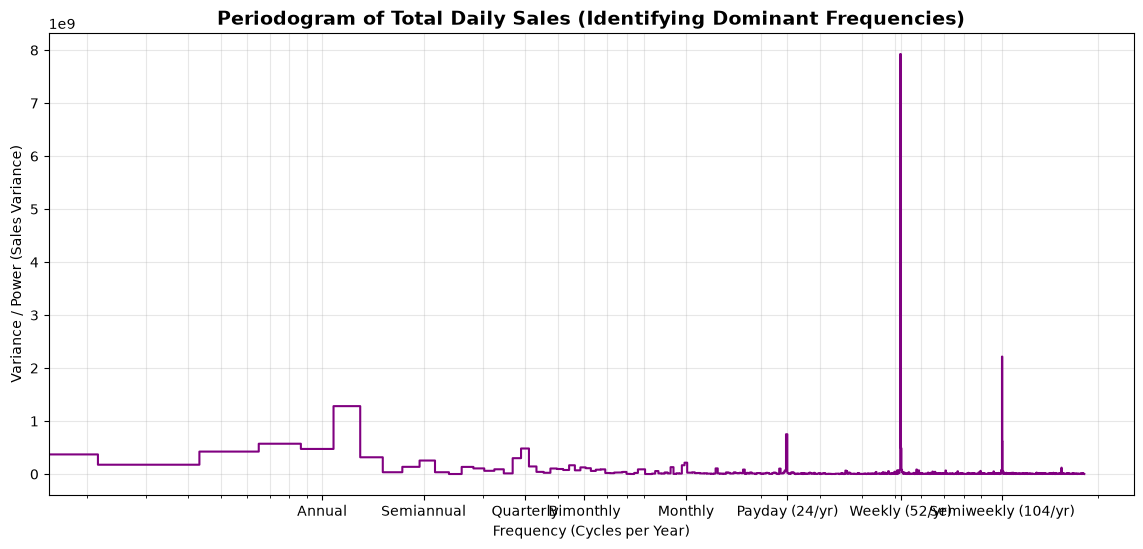

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram

# 1. Aggregate total sales by date on the cleaned df
daily_sales = df.groupby("date")["sales"].sum().asfreq("D")

# Interpolate any missing single dates (like Christmas closures) for continuous frequency analysis
daily_sales = daily_sales.interpolate()

# 2. Compute periodogram (fs=365 assumes 365 observations per year)
freqs, spectrum = periodogram(
    daily_sales,
    fs=365,
    detrend="linear",
    scaling="spectrum"
)

# 3. Plot Periodogram
fig, ax = plt.subplots(figsize=(14, 6))
ax.step(freqs, spectrum, color="purple", linewidth=1.5)
ax.set_xscale("log")

# Label key seasonal frequencies
ax.set_xticks(
    [1, 2, 4, 6, 12, 24, 52, 104],
    labels=[
        "Annual",
        "Semiannual",
        "Quarterly",
        "Bimonthly",
        "Monthly",
        "Payday (24/yr)",
        "Weekly (52/yr)",
        "Semiweekly (104/yr)"
    ]
)

ax.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
ax.set_ylabel("Variance / Power (Sales Variance)")
ax.set_xlabel("Frequency (Cycles per Year)")
ax.set_title("Periodogram of Total Daily Sales (Identifying Dominant Frequencies)", fontsize=14, fontweight="bold")
ax.grid(True, which="both", alpha=0.3)

plt.show()

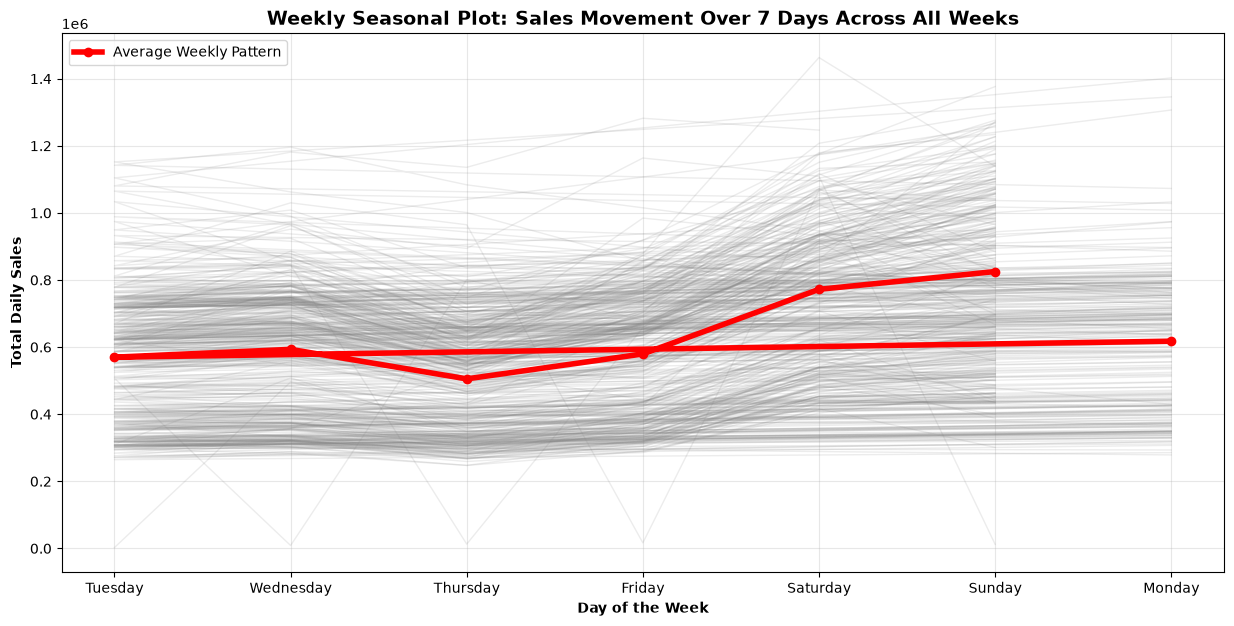

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Clear figure canvas
plt.close('all')

# 2. Aggregate total daily sales from df
seasonal_df = (
    df.groupby("date")["sales"]
    .sum()
    .reset_index()
)

# 3. Extract day name and week identifier
seasonal_df["day"] = seasonal_df["date"].dt.day_name()
seasonal_df["week"] = seasonal_df["date"].dt.to_period("W").astype(str)

# 4. Strict chronological weekday order
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# 5. Compute average per weekday and force exact chronological order
avg_series = seasonal_df.groupby("day")["sales"].mean()
avg_sales_ordered = [avg_series[day] for day in weekday_order]

# 6. Create plot
plt.figure(figsize=(15, 7))

# Plot each individual week (thin gray lines)
for _, week_data in seasonal_df.groupby("week"):
    week_data = week_data.copy()
    week_data["day"] = pd.Categorical(week_data["day"], categories=weekday_order, ordered=True)
    week_data = week_data.sort_values("day")
    plt.plot(
        week_data["day"],
        week_data["sales"],
        color="gray",
        alpha=0.15,
        linewidth=1
    )

# Plot ONLY ONE continuous average line (Monday -> Sunday) in bold red
plt.plot(
    weekday_order,
    avg_sales_ordered,
    color="red",
    linewidth=4,
    marker="o",
    label="Average Weekly Pattern"
)

plt.title("Weekly Seasonal Plot: Sales Movement Over 7 Days Across All Weeks", fontsize=14, fontweight="bold")
plt.xlabel("Day of the Week", fontweight="bold")
plt.ylabel("Total Daily Sales", fontweight="bold")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)

plt.show()

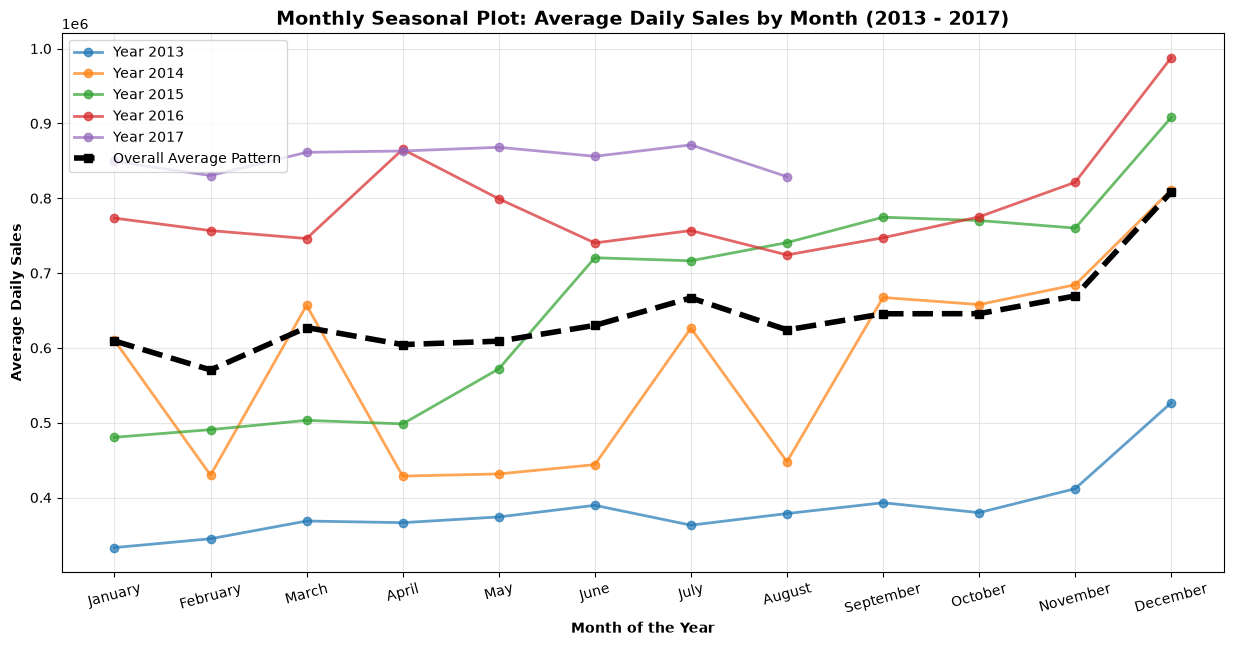

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Clear previous figures
plt.close('all')

# 2. Aggregate total daily sales from df
daily_df = df.groupby("date")["sales"].sum().reset_index()

# 3. Extract month name and year
daily_df["month"] = daily_df["date"].dt.month_name()
daily_df["year"] = daily_df["date"].dt.year

# 4. Strict chronological month ordering (January to December)
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# 5. Compute average daily sales for each (year, month) combination
monthly_avg = daily_df.groupby(["year", "month"], observed=False)["sales"].mean().reset_index()
monthly_avg["month"] = pd.Categorical(monthly_avg["month"], categories=month_order, ordered=True)
monthly_avg = monthly_avg.sort_values(["year", "month"])

# 6. Calculate overall monthly average across all years
overall_monthly_avg = (
    monthly_avg.groupby("month", observed=False)["sales"]
    .mean()
    .reindex(month_order)
)
overall_monthly_ordered = [overall_monthly_avg[m] for m in month_order]

# 7. Create plot
plt.figure(figsize=(15, 7))

# Distinct color for each year
years = sorted(monthly_avg["year"].unique())
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for idx, year in enumerate(years):
    year_data = monthly_avg[monthly_avg["year"] == year].copy()
    year_data = year_data.sort_values("month")
    
    # Plot line for this year
    plt.plot(
        year_data["month"],
        year_data["sales"],
        marker="o",
        linewidth=2,
        alpha=0.7,
        color=colors[idx % len(colors)],
        label=f"Year {year}"
    )

# Plot overall average monthly pattern in bold red
plt.plot(
    month_order,
    overall_monthly_ordered,
    color="black",
    linewidth=4,
    linestyle="--",
    marker="s",
    label="Overall Average Pattern"
)

plt.title("Monthly Seasonal Plot: Average Daily Sales by Month (2013 - 2017)", fontsize=14, fontweight="bold")
plt.xlabel("Month of the Year", fontweight="bold")
plt.ylabel("Average Daily Sales", fontweight="bold")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.xticks(rotation=15)

plt.show()

In [42]:
import pandas as pd

# 1. Add 7 One-Hot Encoded columns for each day of the week
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_name = df["date"].dt.day_name()

for d in days:
    df[f"day_{d}"] = (day_name == d).astype(int)

# 2. Add is_payday_window (1 for mid-month days 15-17 and month-end/start days 30, 31, 1, 2)
day_of_month = df["date"].dt.day
is_month_end = df["date"].dt.is_month_end

df["is_payday_window"] = (
    day_of_month.isin([1, 2, 15, 16, 17]) | is_month_end | (day_of_month >= 30)
).astype(int)

# 3. Verify the new columns added
added_cols = [f"day_{d}" for d in days] + ["is_payday_window"]
print("New Features Added Successfully:")
print(added_cols)
print("\nSample preview:")
print(df[["date"] + added_cols].drop_duplicates().head(5))

New Features Added Successfully:
['day_Monday', 'day_Tuesday', 'day_Wednesday', 'day_Thursday', 'day_Friday', 'day_Saturday', 'day_Sunday', 'is_payday_window']

Sample preview:
           date  day_Monday  day_Tuesday  day_Wednesday  day_Thursday  \
561  2013-01-01           0            1              0             0   
1782 2013-01-02           0            0              1             0   
3564 2013-01-03           0            0              0             1   
5346 2013-01-04           0            0              0             0   
7128 2013-01-05           0            0              0             0   

      day_Friday  day_Saturday  day_Sunday  is_payday_window  
561            0             0           0                 1  
1782           0             0           0                 1  
3564           0             0           0                 0  
5346           1             0           0                 0  
7128           0             1           0                 0  


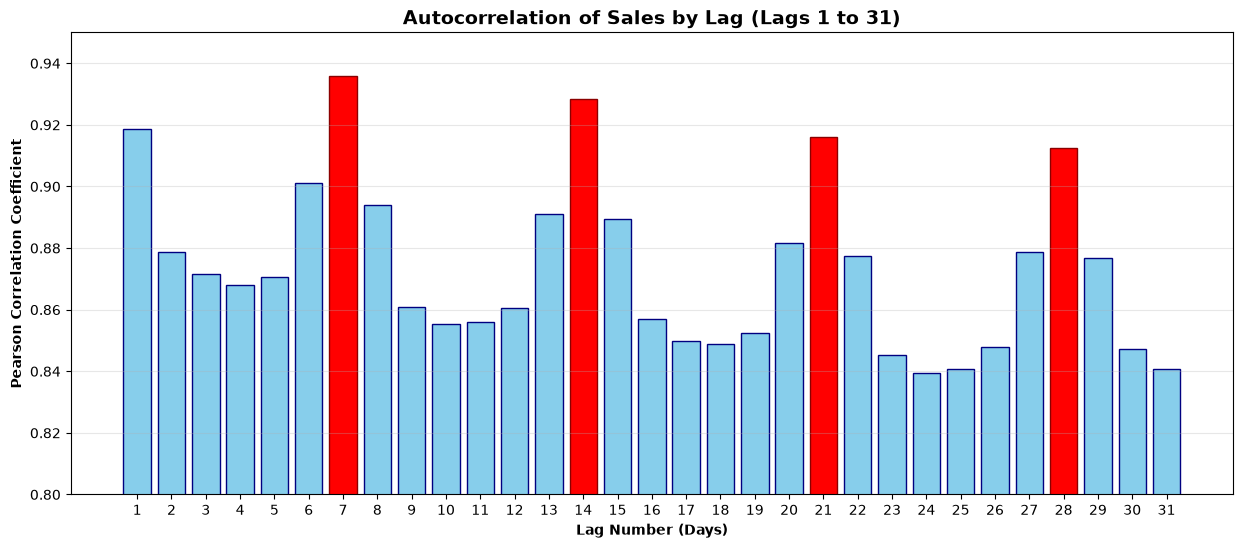

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Sort df chronologically by store, family, and date
df = df.sort_values(by=["store_nbr", "family", "date"]).reset_index(drop=True)

# 2. Calculate grouped autocorrelation for lags 1 to 31
autocorr_list = []

for lag in range(1, 32):
    # Grouped shift by store_nbr and family
    lagged_sales = df.groupby(["store_nbr", "family"])["sales"].shift(lag)
    
    # Calculate Pearson correlation
    corr = df["sales"].corr(lagged_sales)
    autocorr_list.append({"Lag": lag, "Autocorrelation": corr})

autocorr_df = pd.DataFrame(autocorr_list)

# 3. Plot Autocorrelation Bar Chart
plt.figure(figsize=(15, 6))
bars = plt.bar(autocorr_df["Lag"], autocorr_df["Autocorrelation"], color="skyblue", edgecolor="navy")

# Highlight weekly multiple spikes (7, 14, 21, 28) in red
for idx, bar in enumerate(bars):
    if (idx + 1) in [7, 14, 21, 28]:
        bar.set_color("red")
        bar.set_edgecolor("darkred")

plt.title("Autocorrelation of Sales by Lag (Lags 1 to 31)", fontsize=14, fontweight="bold")
plt.xlabel("Lag Number (Days)", fontweight="bold")
plt.ylabel("Pearson Correlation Coefficient", fontweight="bold")
plt.xticks(range(1, 32))
plt.ylim(0.8, 0.95)
plt.grid(axis="y", alpha=0.3)

plt.show()

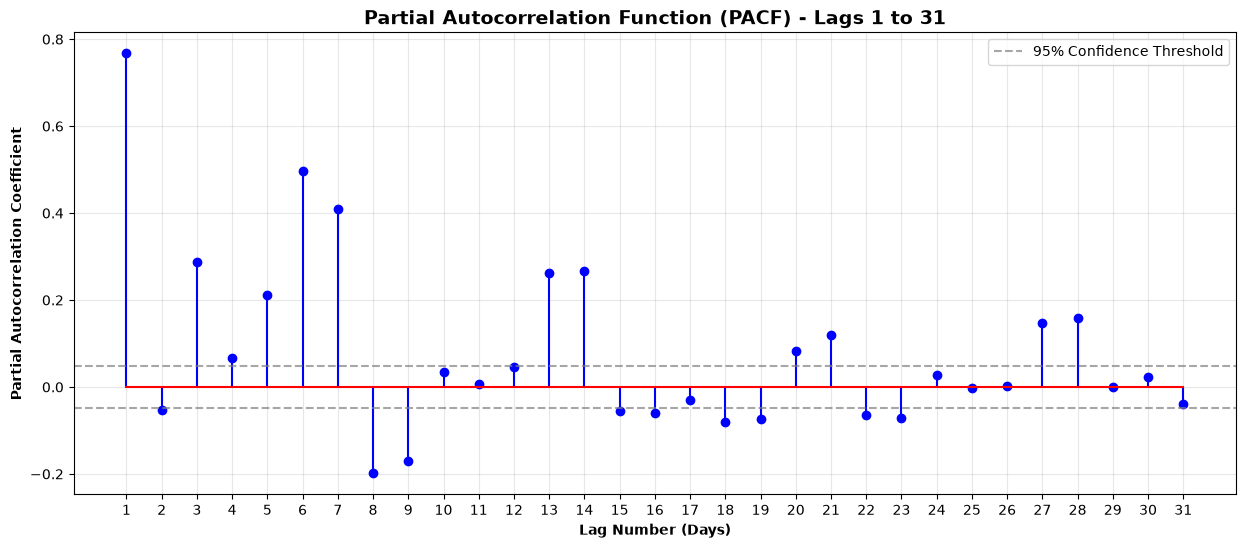

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import pacf

# 1. Aggregate daily total sales from df
daily_sales = df.groupby("date")["sales"].sum().asfreq("D").interpolate()

# 2. Compute PACF for 31 lags
pacf_values = pacf(daily_sales, nlags=31)

# 3. Plot PACF Chart
plt.figure(figsize=(15, 6))
markerline, stemlines, baseline = plt.stem(range(1, 32), pacf_values[1:], linefmt="b-", markerfmt="bo", basefmt="r-")
plt.setp(stemlines, linewidth=1.5)
plt.setp(markerline, markersize=6)

# Add confidence interval threshold (95% confidence bounds)
conf_limit = 1.96 / np.sqrt(len(daily_sales))
plt.axhline(y=conf_limit, color="gray", linestyle="--", alpha=0.7, label="95% Confidence Threshold")
plt.axhline(y=-conf_limit, color="gray", linestyle="--", alpha=0.7)

plt.title("Partial Autocorrelation Function (PACF) - Lags 1 to 31", fontsize=14, fontweight="bold")
plt.xlabel("Lag Number (Days)", fontweight="bold")
plt.ylabel("Partial Autocorrelation Coefficient", fontweight="bold")
plt.xticks(range(1, 32))
plt.grid(alpha=0.3)
plt.legend(loc="upper right")

plt.show()

In [45]:
import pandas as pd

# 1. Sort df chronologically by store_nbr, family, and date to ensure exact group alignment
df = df.sort_values(by=["store_nbr", "family", "date"]).reset_index(drop=True)

# 2. Generate the 5 specified sales lag features grouped by store and family
target_lags = [1, 7, 14, 21, 28]

for lag in target_lags:
    df[f"sales_lag_{lag}"] = df.groupby(["store_nbr", "family"])["sales"].shift(lag)

# 3. Verify the newly generated lag columns for (Store 1, AUTOMOTIVE)
lag_cols = [f"sales_lag_{lag}" for lag in target_lags]
print("New Lag Features Added Successfully:")
print(lag_cols)

# Display sample output to verify exact lag alignment
sample_check = df[(df["store_nbr"] == 1) & (df["family"] == "AUTOMOTIVE")].head(10)
print("\nVerification Sample (Store 1, AUTOMOTIVE):")
print(sample_check[["date", "sales", "sales_lag_1", "sales_lag_7"]])

New Lag Features Added Successfully:
['sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_21', 'sales_lag_28']

Verification Sample (Store 1, AUTOMOTIVE):
        date  sales  sales_lag_1  sales_lag_7
0 2013-01-02    2.0          NaN          NaN
1 2013-01-03    3.0          2.0          NaN
2 2013-01-04    3.0          3.0          NaN
3 2013-01-05    5.0          3.0          NaN
4 2013-01-06    2.0          5.0          NaN
5 2013-01-07    0.0          2.0          NaN
6 2013-01-08    2.0          0.0          NaN
7 2013-01-09    2.0          2.0          2.0
8 2013-01-10    2.0          2.0          3.0
9 2013-01-11    3.0          2.0          3.0


In [46]:
df.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city',
       'state', 'type', 'cluster', 'is_Holiday', 'is_Event', 'oil_price',
       'transactions', 'day_Monday', 'day_Tuesday', 'day_Wednesday',
       'day_Thursday', 'day_Friday', 'day_Saturday', 'day_Sunday',
       'is_payday_window', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14',
       'sales_lag_21', 'sales_lag_28'],
      dtype='str')

In [47]:
import pandas as pd
import numpy as np

# 1. Ensure df is sorted chronologically by store_nbr, family, and date
df = df.sort_values(by=["store_nbr", "family", "date"]).reset_index(drop=True)

# 2. Simple 30-day trailing moving average on sales (center=False, min_periods=1)
df["sales_roll_mean_30"] = df.groupby(["store_nbr", "family"])["sales"].transform(
    lambda x: x.rolling(window=30, center=False, min_periods=1).mean()
)

# 3. Simple 7-day trailing standard deviation on sales (center=False, min_periods=1)
df["sales_roll_std_7"] = df.groupby(["store_nbr", "family"])["sales"].transform(
    lambda x: x.rolling(window=7, center=False, min_periods=1).std()
).fillna(0)

# 4. Verify the new features
simple_rolling_cols = ["sales_roll_mean_30", "sales_roll_std_7"]
print("Simple Trailing Rolling Features Created Successfully:")
print(simple_rolling_cols)

# Display sample inspection for (Store 1, AUTOMOTIVE)
sample_check = df[(df["store_nbr"] == 1) & (df["family"] == "AUTOMOTIVE")].head(10)
print("\nVerification Sample (Store 1, AUTOMOTIVE):")
print(sample_check[["date", "sales"] + simple_rolling_cols])

Simple Trailing Rolling Features Created Successfully:
['sales_roll_mean_30', 'sales_roll_std_7']

Verification Sample (Store 1, AUTOMOTIVE):
        date  sales  sales_roll_mean_30  sales_roll_std_7
0 2013-01-02    2.0            2.000000          0.000000
1 2013-01-03    3.0            2.500000          0.707107
2 2013-01-04    3.0            2.666667          0.577350
3 2013-01-05    5.0            3.250000          1.258306
4 2013-01-06    2.0            3.000000          1.224745
5 2013-01-07    0.0            2.500000          1.643168
6 2013-01-08    2.0            2.428571          1.511858
7 2013-01-09    2.0            2.375000          1.511858
8 2013-01-10    2.0            2.333333          1.496026
9 2013-01-11    3.0            2.400000          1.496026


In [48]:
df.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city',
       'state', 'type', 'cluster', 'is_Holiday', 'is_Event', 'oil_price',
       'transactions', 'day_Monday', 'day_Tuesday', 'day_Wednesday',
       'day_Thursday', 'day_Friday', 'day_Saturday', 'day_Sunday',
       'is_payday_window', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14',
       'sales_lag_21', 'sales_lag_28', 'sales_roll_mean_30',
       'sales_roll_std_7'],
      dtype='str')

In [49]:
import pandas as pd

# 1. Extract all unique dates from df, sorted chronologically
unique_oil_df = pd.DataFrame({"date": sorted(df["date"].unique())})

# Map the existing oil_price from df onto the unique date table
unique_oil_df["oil_price"] = unique_oil_df["date"].map(dict(zip(df["date"], df["oil_price"])))

# 2. Compute 30-day Centered Rolling Mean on unique daily dates
unique_oil_df["oil_roll_mean_30"] = unique_oil_df["oil_price"].rolling(window=30, center=True, min_periods=1).mean()

# 3. Compute 7-day Price Difference (Shock) on unique daily dates
unique_oil_df["oil_diff_7"] = unique_oil_df["oil_price"].diff(7).fillna(0)

# 4. Map the newly manufactured features back to df by date
df["oil_roll_mean_30"] = df["date"].map(dict(zip(unique_oil_df["date"], unique_oil_df["oil_roll_mean_30"])))
df["oil_diff_7"] = df["date"].map(dict(zip(unique_oil_df["date"], unique_oil_df["oil_diff_7"])))

# 5. Verify the features added
oil_cols = ["oil_price", "oil_roll_mean_30", "oil_diff_7"]
print("Oil Features Added Successfully:")
print(oil_cols)
print("\nSample Preview:")
print(df[["date"] + oil_cols].drop_duplicates().head(7))

Oil Features Added Successfully:
['oil_price', 'oil_roll_mean_30', 'oil_diff_7']

Sample Preview:
        date  oil_price  oil_roll_mean_30  oil_diff_7
0 2013-01-02  93.140000         93.585386       0.000
1 2013-01-03  92.970000         93.697422       0.000
2 2013-01-04  93.120000         93.803676       0.000
3 2013-01-05  93.772308         93.878035       0.000
4 2013-01-06  93.772308         93.944959       0.000
5 2013-01-07  93.200000         94.005508       0.000
6 2013-01-08  93.210000         94.100258      -0.156


In [50]:
import pandas as pd
import numpy as np

# 1. Create a store daily dataframe (date, store_nbr, transactions)
daily_store = df.groupby(["date", "store_nbr"]).agg(
    total_sales=("sales", "sum"),
    transactions=("transactions", "first")
).reset_index()

# 2. Sort chronologically by store_nbr and date
daily_store = daily_store.sort_values(by=["store_nbr", "date"]).reset_index(drop=True)

# 3. Manufacture Transaction Lags (Lag 1 and Lag 7)
daily_store["trans_lag_1"] = daily_store.groupby("store_nbr")["transactions"].shift(1).fillna(0)
daily_store["trans_lag_7"] = daily_store.groupby("store_nbr")["transactions"].shift(7).fillna(0)

# 4. Manufacture Trailing Rolling Means (center=False, min_periods=1)
daily_store["trans_roll_mean_7"] = daily_store.groupby("store_nbr")["transactions"].transform(
    lambda x: x.rolling(window=7, center=False, min_periods=1).mean()
)
daily_store["trans_roll_mean_30"] = daily_store.groupby("store_nbr")["transactions"].transform(
    lambda x: x.rolling(window=30, center=False, min_periods=1).mean()
)

# 5. Clean up any leftover transaction feature columns in df before merging
trans_feature_cols = ["trans_lag_1", "trans_lag_7", "trans_roll_mean_7", "trans_roll_mean_30"]
for col in trans_feature_cols:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# 6. Merge the manufactured transaction features back into main df
df = df.merge(
    daily_store[["date", "store_nbr"] + trans_feature_cols],
    on=["date", "store_nbr"],
    how="left"
)

# 7. Verify features added for Store 1 on 2013-01-10
print("Transaction Features Manufactured Successfully:")
print(trans_feature_cols)

sample_check = df[(df["store_nbr"] == 1) & (df["date"] == "2013-01-10")].head(1)
print("\nVerification Sample (Store 1 on 2013-01-10):")
print(sample_check[["date", "store_nbr"] + trans_feature_cols])

Transaction Features Manufactured Successfully:
['trans_lag_1', 'trans_lag_7', 'trans_roll_mean_7', 'trans_roll_mean_30']

Verification Sample (Store 1 on 2013-01-10):
        date  store_nbr  trans_lag_1  trans_lag_7  trans_roll_mean_7  \
8 2013-01-10          1       1910.0       1833.0        1593.857143   

   trans_roll_mean_30  
8         1677.888889  


In [51]:
df.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city',
       'state', 'type', 'cluster', 'is_Holiday', 'is_Event', 'oil_price',
       'transactions', 'day_Monday', 'day_Tuesday', 'day_Wednesday',
       'day_Thursday', 'day_Friday', 'day_Saturday', 'day_Sunday',
       'is_payday_window', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14',
       'sales_lag_21', 'sales_lag_28', 'sales_roll_mean_30',
       'sales_roll_std_7', 'oil_roll_mean_30', 'oil_diff_7', 'trans_lag_1',
       'trans_lag_7', 'trans_roll_mean_7', 'trans_roll_mean_30'],
      dtype='str')

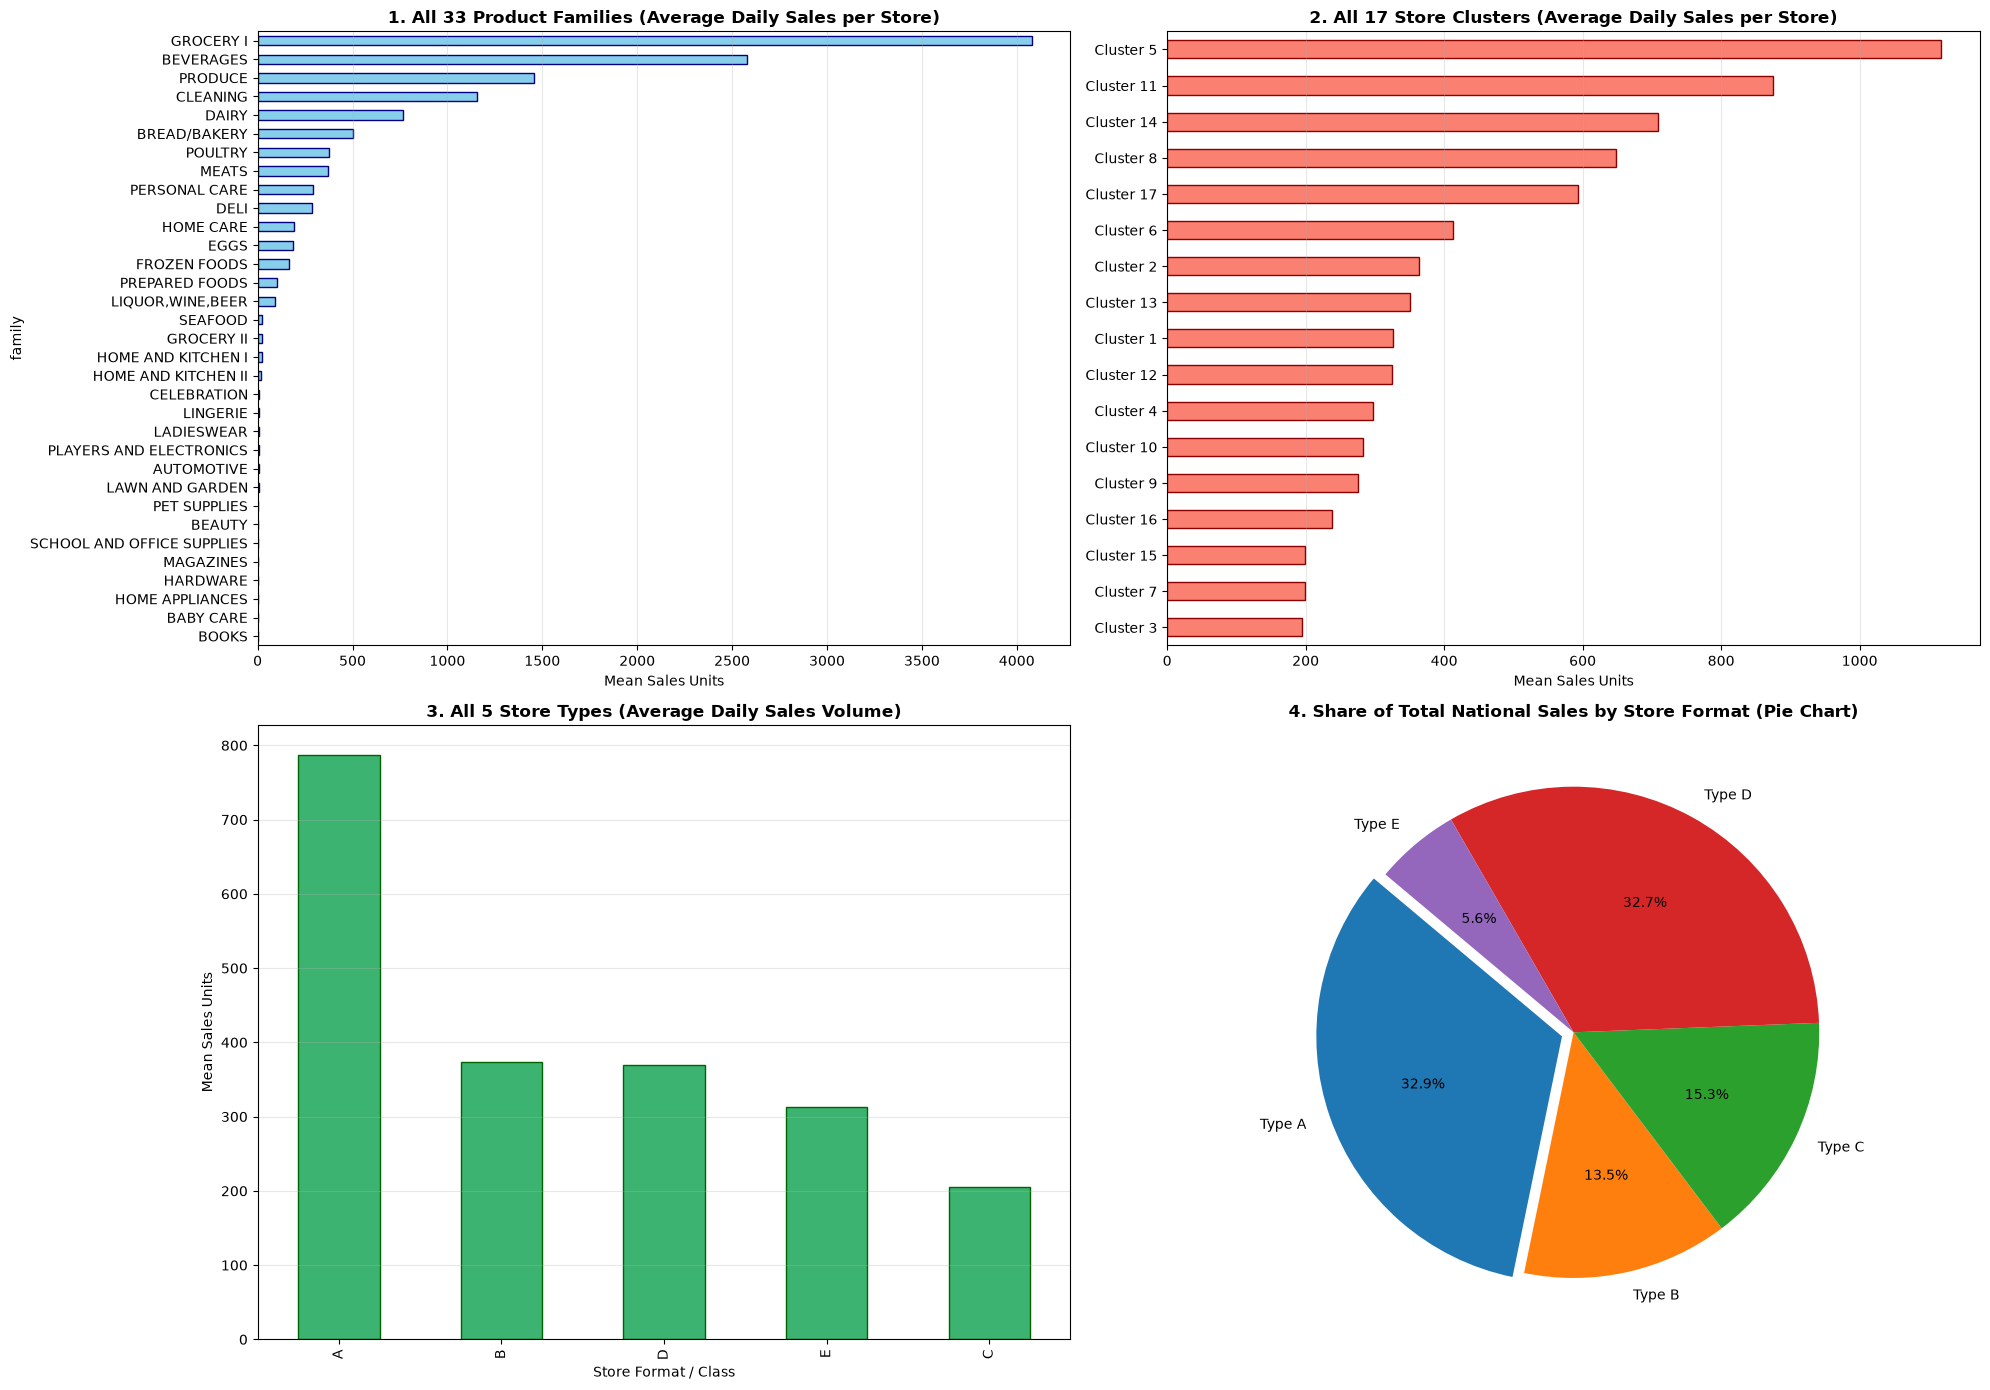

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

plt.close('all')

# Create a 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# --- Chart 1: ALL 33 Product Families (Horizontal Bar Chart) ---
fam_sales = df.groupby("family")["sales"].mean().sort_values(ascending=True)
fam_sales.plot(kind="barh", ax=axes[0, 0], color="skyblue", edgecolor="navy")
axes[0, 0].set_title("1. All 33 Product Families (Average Daily Sales per Store)", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Mean Sales Units")
axes[0, 0].grid(axis="x", alpha=0.3)

# --- Chart 2: ALL 17 Store Clusters (Horizontal Bar Chart) ---
cluster_sales = df.groupby("cluster")["sales"].mean().sort_values(ascending=True)
cluster_sales.index = [f"Cluster {c}" for c in cluster_sales.index]
cluster_sales.plot(kind="barh", ax=axes[0, 1], color="salmon", edgecolor="darkred")
axes[0, 1].set_title("2. All 17 Store Clusters (Average Daily Sales per Store)", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Mean Sales Units")
axes[0, 1].grid(axis="x", alpha=0.3)

# --- Chart 3: ALL 5 Store Formats (Vertical Bar Chart) ---
type_sales = df.groupby("type")["sales"].mean().sort_values(ascending=False)
type_sales.plot(kind="bar", ax=axes[1, 0], color="mediumseagreen", edgecolor="darkgreen")
axes[1, 0].set_title("3. All 5 Store Types (Average Daily Sales Volume)", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Mean Sales Units")
axes[1, 0].set_xlabel("Store Format / Class")
axes[1, 0].grid(axis="y", alpha=0.3)

# --- Chart 4: Share of Total Sales by Store Format (Pie Chart) ---
type_total_sales = df.groupby("type")["sales"].sum()
axes[1, 1].pie(
    type_total_sales, 
    labels=[f"Type {t}" for t in type_total_sales.index], 
    autopct="%1.1f%%", 
    colors=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"],
    startangle=140,
    explode=(0.05, 0, 0, 0, 0)
)
axes[1, 1].set_title("4. Share of Total National Sales by Store Format (Pie Chart)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [53]:
import pandas as pd

# 1. Compute Static Historical Averages (Option A)
mean_family = df.groupby("family")["sales"].mean().to_dict()
mean_store = df.groupby("store_nbr")["sales"].mean().to_dict()
mean_cluster = df.groupby("cluster")["sales"].mean().to_dict()
mean_type = df.groupby("type")["sales"].mean().to_dict()

# 2. Map the static averages onto df
df["mean_sales_by_family"] = df["family"].map(mean_family)
df["mean_sales_by_store"] = df["store_nbr"].map(mean_store)
df["mean_sales_by_cluster"] = df["cluster"].map(mean_cluster)
df["mean_sales_by_type"] = df["type"].map(mean_type)

# 3. Verify features added
static_cols = ["mean_sales_by_family", "mean_sales_by_store", "mean_sales_by_cluster", "mean_sales_by_type"]
print("Static Target Encoded Features Created Successfully:")
print(static_cols)
print(f"\nAny NaNs remaining: {df[static_cols].isnull().sum().sum()}")

# Display sample inspection for Store 1
print("\nSample Benchmark Inspection (Store 1):")
print(df[["store_nbr", "family", "cluster", "type"] + static_cols].drop_duplicates().head(5))

Static Target Encoded Features Created Successfully:
['mean_sales_by_family', 'mean_sales_by_store', 'mean_sales_by_cluster', 'mean_sales_by_type']

Any NaNs remaining: 0

Sample Benchmark Inspection (Store 1):
      store_nbr      family  cluster type  mean_sales_by_family  \
0             1  AUTOMOTIVE       13    D              6.588787   
1683          1   BABY CARE       13    D              0.119361   
3366          1      BEAUTY       13    D              4.012647   
5049          1   BEVERAGES       13    D           2576.442410   
6732          1       BOOKS       13    D              0.076454   

      mean_sales_by_store  mean_sales_by_cluster  mean_sales_by_type  
0              254.686128             351.216304          369.085439  
1683           254.686128             351.216304          369.085439  
3366           254.686128             351.216304          369.085439  
5049           254.686128             351.216304          369.085439  
6732           254.686128      

In [54]:
import pandas as pd
import numpy as np

# 1. Calculate non-promotion vs promotion days for every (store_nbr, family) pair
promo_summary = (
    df.groupby(["store_nbr", "family"])["onpromotion"]
    .agg(
        total_days="count",
        no_promo_days=lambda x: (x == 0).sum(),
        promo_days=lambda x: (x > 0).sum()
    )
    .reset_index()
)

# 2. Inverted Ratio: (promo_days / no_promo_days)
promo_summary["ratio_promo_to_no_promo"] = np.where(
    promo_summary["no_promo_days"] > 0,
    (promo_summary["promo_days"] / promo_summary["no_promo_days"]).round(4),
    np.nan
)

# 3. Percentage of days with active promotion
promo_summary["pct_days_with_promo"] = (
    (promo_summary["promo_days"] / promo_summary["total_days"]) * 100
).round(2)

# 4. Preview sample output for Store 1
print("=== PROMOTION RATIO SUMMARY (promo_days / no_promo_days) ===")
print(promo_summary[promo_summary["store_nbr"] == 1].head(10).to_string(index=False))

=== PROMOTION RATIO SUMMARY (promo_days / no_promo_days) ===
 store_nbr       family  total_days  no_promo_days  promo_days  ratio_promo_to_no_promo  pct_days_with_promo
         1   AUTOMOTIVE        1683           1669          14                   0.0084                 0.83
         1    BABY CARE        1683           1683           0                   0.0000                 0.00
         1       BEAUTY        1683           1464         219                   0.1496                13.01
         1    BEVERAGES        1683            664        1019                   1.5346                60.55
         1        BOOKS        1683           1683           0                   0.0000                 0.00
         1 BREAD/BAKERY        1683            925         758                   0.8195                45.04
         1  CELEBRATION        1683           1626          57                   0.0351                 3.39
         1     CLEANING        1683            716         967     

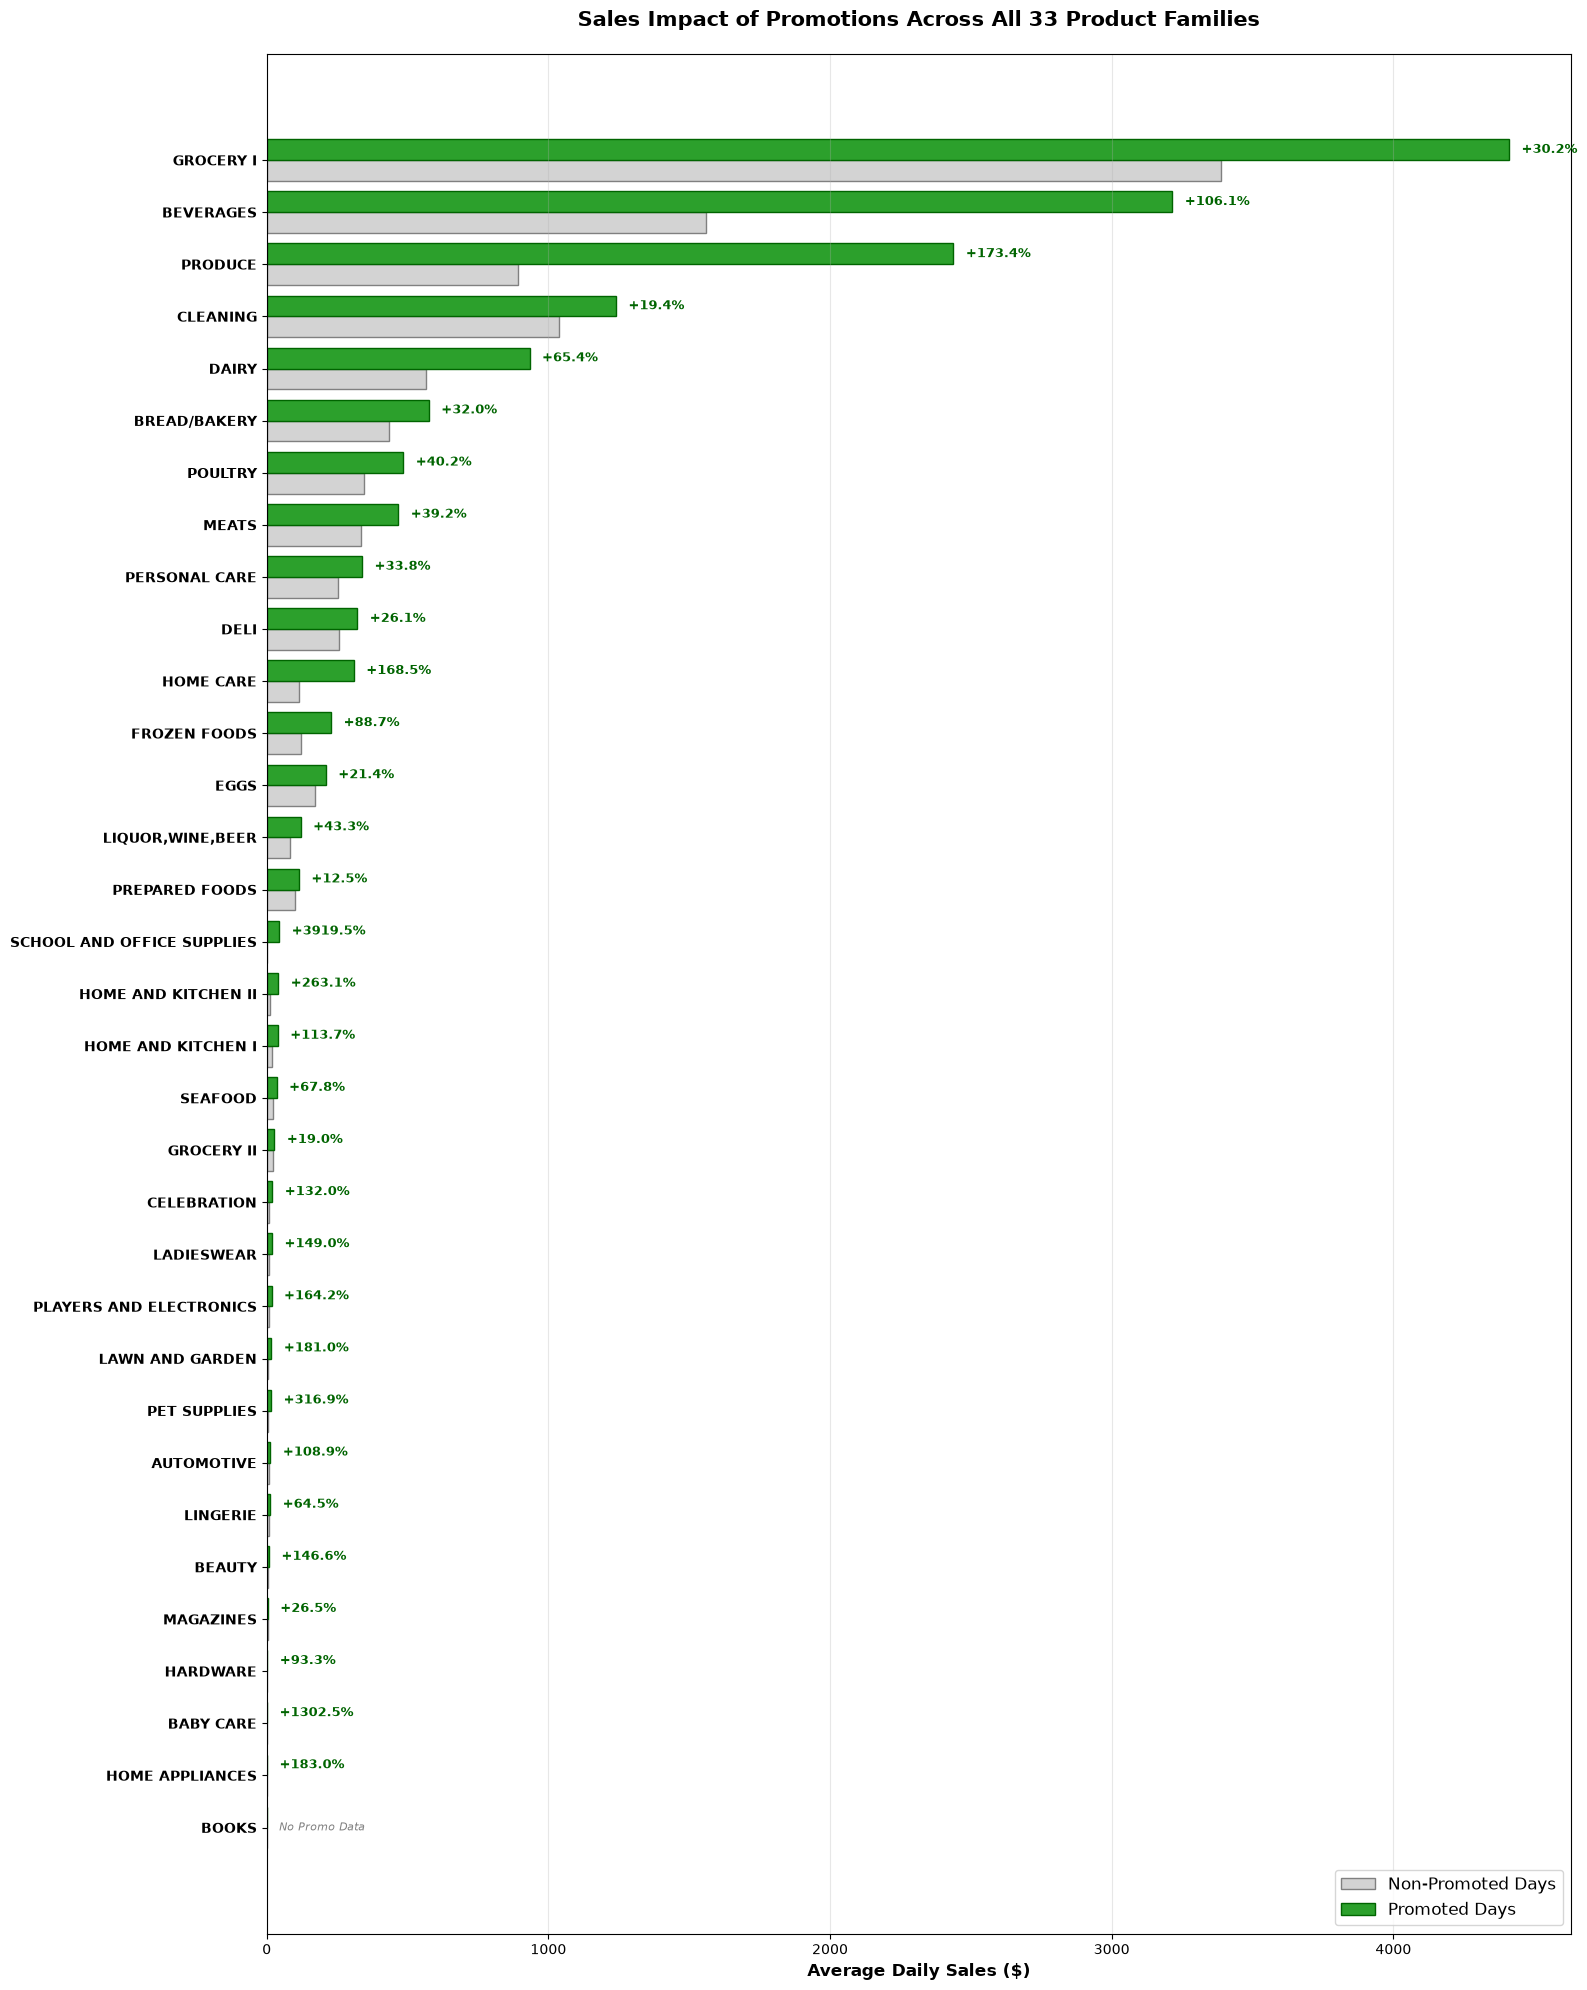

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Clear figure canvas
plt.close('all')

# 2. Calculate average daily sales on Non-Promo vs Promo days for ALL 33 families
promo_sales_all = (
    df.groupby(["family", df["onpromotion"] > 0])["sales"]
    .mean()
    .unstack(fill_value=0)
)
promo_sales_all.columns = ["No_Promo_Sales", "Promo_Sales"]

# 3. Calculate percentage uplift
promo_sales_all["Uplift_Pct"] = np.where(
    promo_sales_all["No_Promo_Sales"] > 0,
    ((promo_sales_all["Promo_Sales"] - promo_sales_all["No_Promo_Sales"]) / promo_sales_all["No_Promo_Sales"]) * 100,
    0
)

# Sort all 33 families by Promo_Sales ascending so highest is at top
all_33_sorted = promo_sales_all.sort_values(by="Promo_Sales", ascending=True)

# 4. Plot Horizontal Bar Chart for all 33 families
fig, ax = plt.subplots(figsize=(16, 20))

y_positions = np.arange(len(all_33_sorted))
bar_width = 0.40

rects1 = ax.barh(
    y_positions - bar_width/2, 
    all_33_sorted["No_Promo_Sales"], 
    bar_width, 
    label="Non-Promoted Days", 
    color="lightgray", 
    edgecolor="gray"
)

rects2 = ax.barh(
    y_positions + bar_width/2, 
    all_33_sorted["Promo_Sales"], 
    bar_width, 
    label="Promoted Days", 
    color="#2ca02c", 
    edgecolor="darkgreen"
)

# 5. Add percentage uplift labels for every family
for idx, (no_p, p, uplift) in enumerate(zip(all_33_sorted["No_Promo_Sales"], all_33_sorted["Promo_Sales"], all_33_sorted["Uplift_Pct"])):
    if p > 0 and no_p > 0:
        ax.text(p + max(all_33_sorted["Promo_Sales"])*0.01, y_positions[idx] + bar_width/2, f"+{uplift:.1f}%", va="center", fontweight="bold", color="darkgreen", fontsize=9)
    elif p == 0:
        ax.text(no_p + max(all_33_sorted["Promo_Sales"])*0.01, y_positions[idx], "No Promo Data", va="center", fontstyle="italic", color="gray", fontsize=8)

ax.set_yticks(y_positions)
ax.set_yticklabels(all_33_sorted.index, fontweight="bold", fontsize=10)
ax.set_xlabel("Average Daily Sales ($)", fontweight="bold", fontsize=12)
ax.set_title("Sales Impact of Promotions Across All 33 Product Families", fontsize=15, fontweight="bold", pad=20)
ax.legend(loc="lower right", fontsize=12)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [56]:
import pandas as pd
import numpy as np

# Load train_df
train_df = pd.read_csv("data/raw/train.csv")

# Group by family and promo status for all 33 families
promo_sales = train_df.groupby(["family", train_df["onpromotion"] > 0])["sales"].mean().unstack(fill_value=0)
promo_sales.columns = ["No_Promo_Sales", "Promo_Sales"]

# 1. Absolute Dollar Sales Difference
promo_sales["Dollar_Diff"] = promo_sales["Promo_Sales"] - promo_sales["No_Promo_Sales"]

# 2. Percentage Uplift
promo_sales["Uplift_Pct"] = np.where(
    promo_sales["No_Promo_Sales"] > 0,
    (promo_sales["Dollar_Diff"] / promo_sales["No_Promo_Sales"]) * 100,
    0
)

# Sort all 33 families by Dollar_Diff ascending
all_33_sorted = promo_sales.sort_values(by="Dollar_Diff", ascending=True)

print("--- Top 10 Families by Absolute Dollar Sales Gain on Promotion ---")
print(all_33_sorted.tail(10)[["No_Promo_Sales", "Promo_Sales", "Dollar_Diff", "Uplift_Pct"]].to_string())

--- Top 10 Families by Absolute Dollar Sales Gain on Promotion ---
              No_Promo_Sales  Promo_Sales  Dollar_Diff  Uplift_Pct
family                                                            
FROZEN FOODS      106.524349   228.997534   122.473185  114.972009
MEATS             303.081088   467.301631   164.220543   54.183699
POULTRY           313.334513   485.006113   171.671600   54.788602
BREAD/BAKERY      379.513249   575.485296   195.972047   51.637735
HOME CARE         101.956009   309.444864   207.488856  203.508217
CLEANING          868.378326  1240.210741   371.832415   42.819173
DAIRY             479.811128   933.341720   453.530592   94.522733
PRODUCE           792.101911  2438.220197  1646.118286  207.816477
GROCERY I        2717.720813  4411.003431  1693.282618   62.305245
BEVERAGES        1292.272591  3215.498308  1923.225717  148.825080


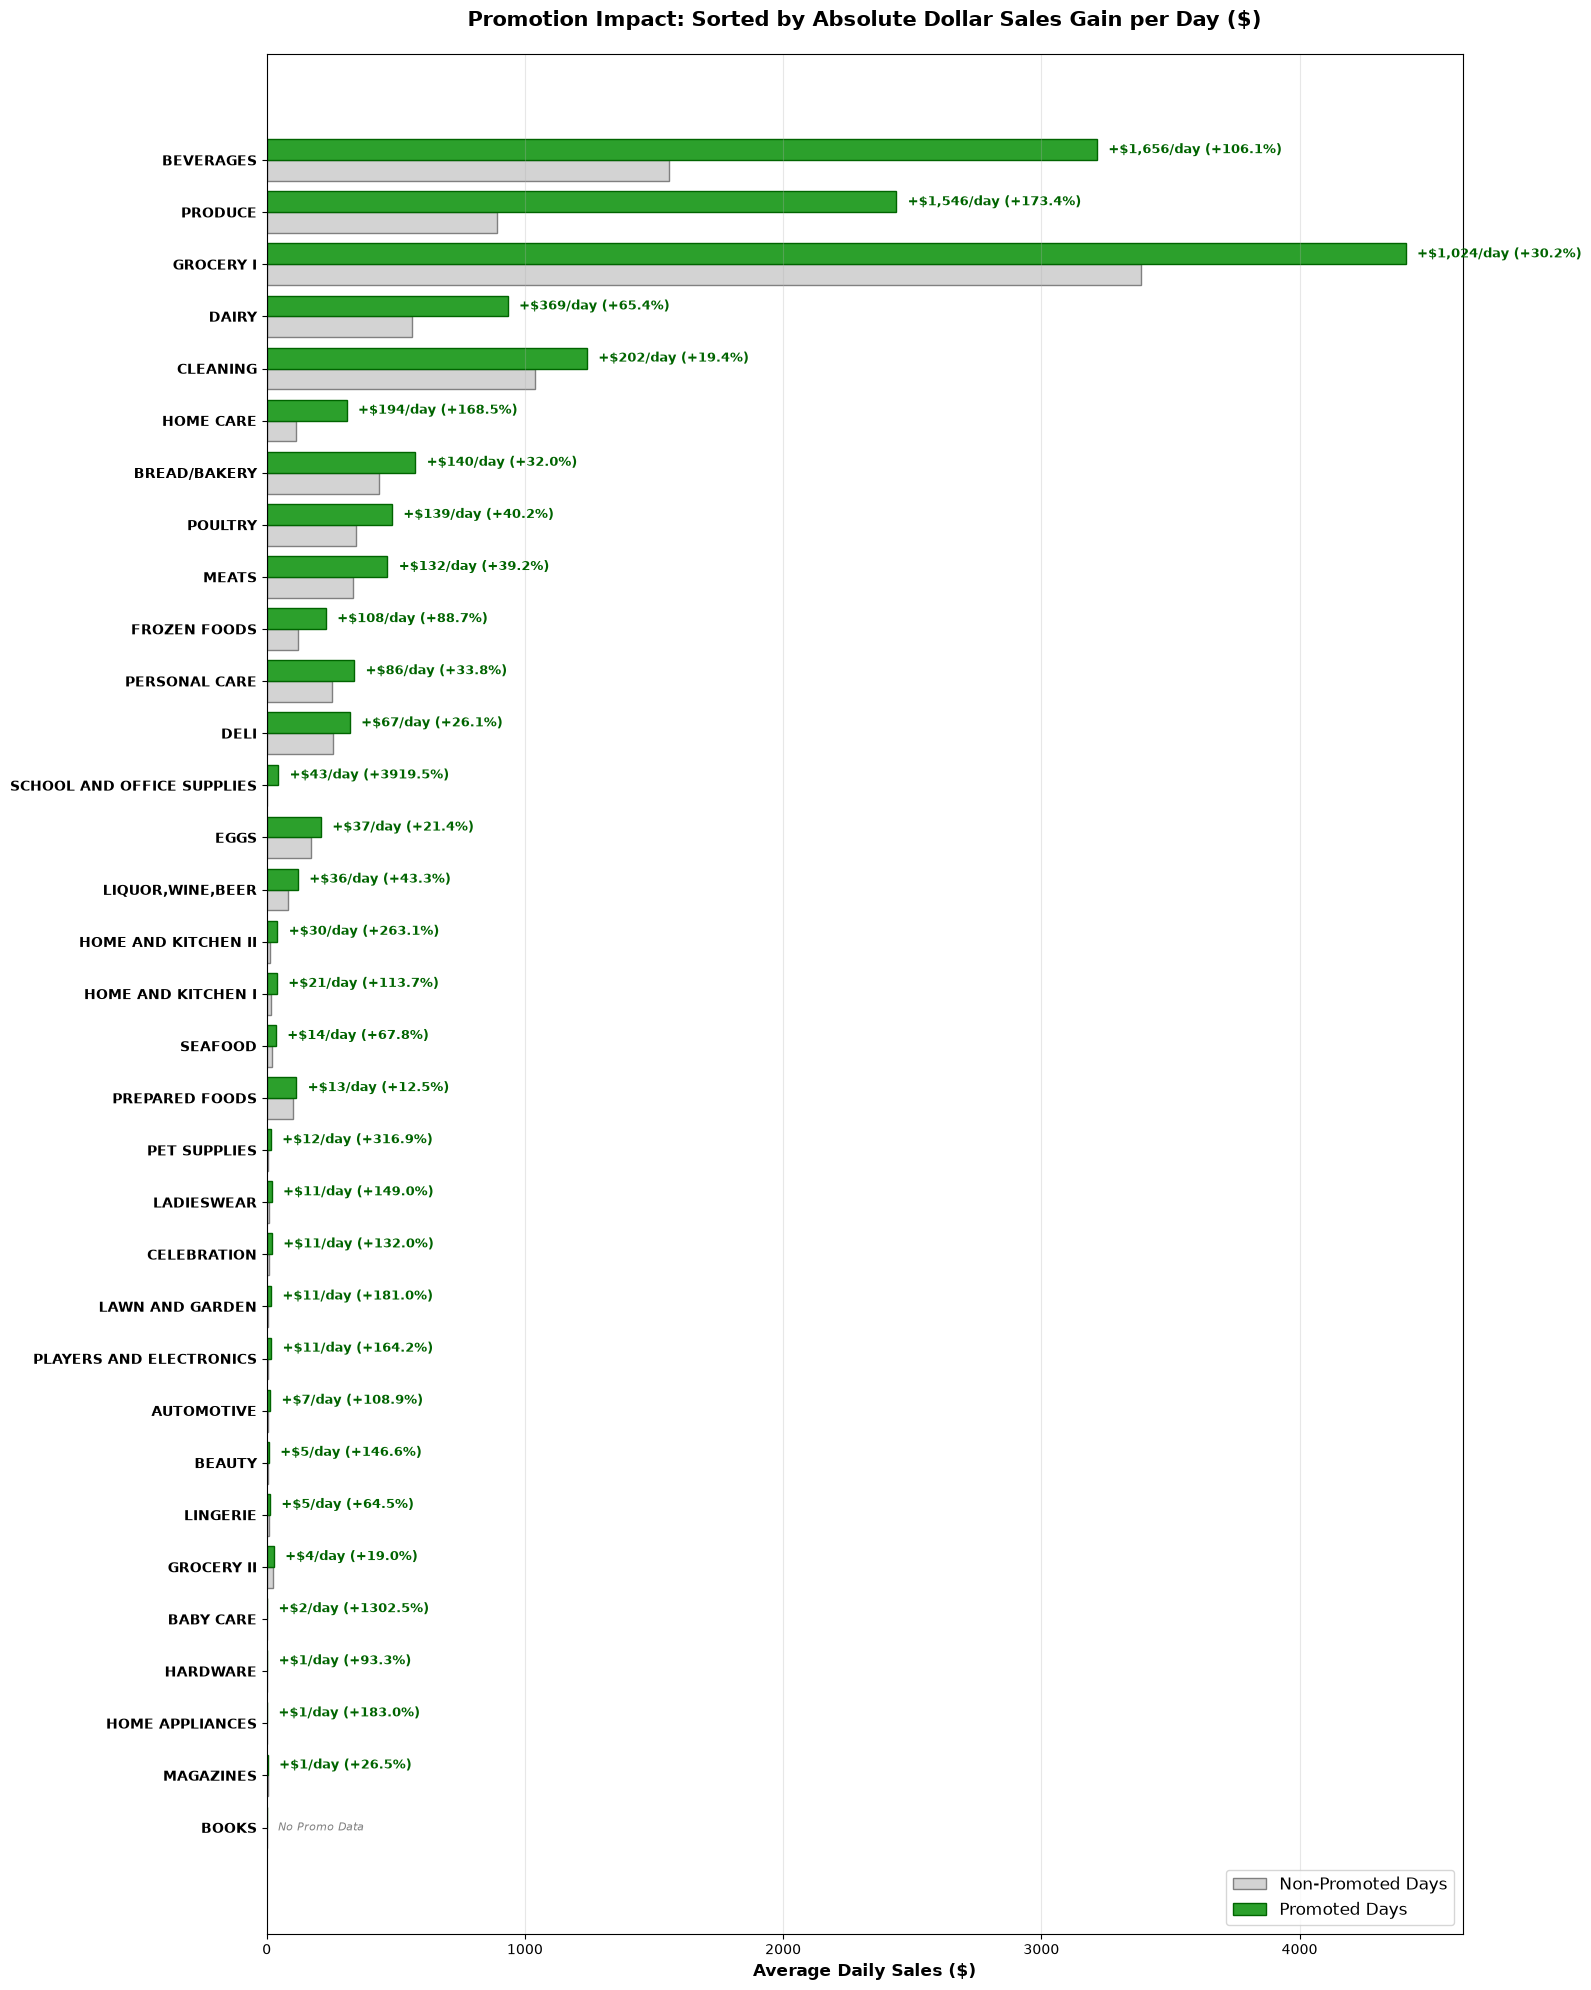

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Clear figure canvas
plt.close('all')

# 2. Calculate average daily sales on Non-Promo vs Promo days for ALL 33 families
promo_sales_all = (
    df.groupby(["family", df["onpromotion"] > 0])["sales"]
    .mean()
    .unstack(fill_value=0)
)
promo_sales_all.columns = ["No_Promo_Sales", "Promo_Sales"]

# 3. Calculate Absolute Dollar Difference and Percentage Uplift
promo_sales_all["Dollar_Diff"] = promo_sales_all["Promo_Sales"] - promo_sales_all["No_Promo_Sales"]

promo_sales_all["Uplift_Pct"] = np.where(
    promo_sales_all["No_Promo_Sales"] > 0,
    (promo_sales_all["Dollar_Diff"] / promo_sales_all["No_Promo_Sales"]) * 100,
    0
)

# 4. SORT strictly by Absolute Dollar Difference ascending (so largest gain is at the top)
all_33_sorted = promo_sales_all.sort_values(by="Dollar_Diff", ascending=True)

# 5. Plot Horizontal Bar Chart
fig, ax = plt.subplots(figsize=(16, 20))

y_positions = np.arange(len(all_33_sorted))
bar_width = 0.40

rects1 = ax.barh(
    y_positions - bar_width/2, 
    all_33_sorted["No_Promo_Sales"], 
    bar_width, 
    label="Non-Promoted Days", 
    color="lightgray", 
    edgecolor="gray"
)

rects2 = ax.barh(
    y_positions + bar_width/2, 
    all_33_sorted["Promo_Sales"], 
    bar_width, 
    label="Promoted Days", 
    color="#2ca02c", 
    edgecolor="darkgreen"
)

# 6. Annotate BOTH Dollar Gain ($/day) and Percentage Uplift (%) next to every bar
for idx, (no_p, p, diff, uplift) in enumerate(zip(all_33_sorted["No_Promo_Sales"], all_33_sorted["Promo_Sales"], all_33_sorted["Dollar_Diff"], all_33_sorted["Uplift_Pct"])):
    if p > 0 and no_p > 0:
        label_text = f"+${diff:,.0f}/day (+{uplift:.1f}%)"
        ax.text(p + max(all_33_sorted["Promo_Sales"])*0.01, y_positions[idx] + bar_width/2, label_text, va="center", fontweight="bold", color="darkgreen", fontsize=9)
    elif p == 0:
        ax.text(no_p + max(all_33_sorted["Promo_Sales"])*0.01, y_positions[idx], "No Promo Data", va="center", fontstyle="italic", color="gray", fontsize=8)

ax.set_yticks(y_positions)
ax.set_yticklabels(all_33_sorted.index, fontweight="bold", fontsize=10)
ax.set_xlabel("Average Daily Sales ($)", fontweight="bold", fontsize=12)
ax.set_title("Promotion Impact: Sorted by Absolute Dollar Sales Gain per Day ($)", fontsize=15, fontweight="bold", pad=20)
ax.legend(loc="lower right", fontsize=12)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [58]:
import pandas as pd
import numpy as np

# 1. Compute historical average sales per family on promo vs non-promo days
family_stats = df.groupby(["family", df["onpromotion"] > 0])["sales"].mean().unstack(fill_value=0)
family_stats.columns = ["No_Promo_Sales", "Promo_Sales"]

# 2. Feature 2: family_dollar_diff (Absolute dollar gain per day)
family_stats["family_dollar_diff"] = family_stats["Promo_Sales"] - family_stats["No_Promo_Sales"]

# Compute multiplier ratio (Promo_Sales / No_Promo_Sales)
family_stats["family_promo_ratio"] = np.where(
    family_stats["No_Promo_Sales"] > 0,
    family_stats["Promo_Sales"] / family_stats["No_Promo_Sales"],
    1.0
)

# 3. Map family_dollar_diff and family_promo_ratio to df by family name
df["family_dollar_diff"] = df["family"].map(family_stats["family_dollar_diff"])
df["family_promo_ratio"] = df["family"].map(family_stats["family_promo_ratio"])

# 4. Feature 1: expected_promo_boost (onpromotion * family_promo_ratio)
df["expected_promo_boost"] = df["onpromotion"] * df["family_promo_ratio"]

# 5. Clean up temporary helper column
df.drop(columns=["family_promo_ratio"], inplace=True)

# 6. Verify features added
print("Features 1 & 2 Implemented Successfully!")
print(f"NaNs in expected_promo_boost: {df['expected_promo_boost'].isnull().sum()}")
print(f"NaNs in family_dollar_diff:   {df['family_dollar_diff'].isnull().sum()}")

Features 1 & 2 Implemented Successfully!
NaNs in expected_promo_boost: 0
NaNs in family_dollar_diff:   0


In [59]:
df.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city',
       'state', 'type', 'cluster', 'is_Holiday', 'is_Event', 'oil_price',
       'transactions', 'day_Monday', 'day_Tuesday', 'day_Wednesday',
       'day_Thursday', 'day_Friday', 'day_Saturday', 'day_Sunday',
       'is_payday_window', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14',
       'sales_lag_21', 'sales_lag_28', 'sales_roll_mean_30',
       'sales_roll_std_7', 'oil_roll_mean_30', 'oil_diff_7', 'trans_lag_1',
       'trans_lag_7', 'trans_roll_mean_7', 'trans_roll_mean_30',
       'mean_sales_by_family', 'mean_sales_by_store', 'mean_sales_by_cluster',
       'mean_sales_by_type', 'family_dollar_diff', 'expected_promo_boost'],
      dtype='str')

In [60]:
import pandas as pd

# 1. Load test.csv
test_df = pd.read_csv("data/raw/test.csv")

# 2. Convert date column to datetime format
test_df['date'] = pd.to_datetime(test_df['date'], format='%Y-%m-%d')

# 3. Print verification info and date range
print("test_df Loaded Successfully!")
print(f"Shape: {test_df.shape}")
print(f"Date Range: {test_df['date'].min().strftime('%Y-%m-%d')} to {test_df['date'].max().strftime('%Y-%m-%d')}")
print("\nPreview:")
print(test_df.head())

test_df Loaded Successfully!
Shape: (28512, 5)
Date Range: 2017-08-16 to 2017-08-31

Preview:
        id       date  store_nbr      family  onpromotion
0  3000888 2017-08-16          1  AUTOMOTIVE            0
1  3000889 2017-08-16          1   BABY CARE            0
2  3000890 2017-08-16          1      BEAUTY            2
3  3000891 2017-08-16          1   BEVERAGES           20
4  3000892 2017-08-16          1       BOOKS            0


In [61]:
test_df.isnull().sum()

id             0
date           0
store_nbr      0
family         0
onpromotion    0
dtype: int64

In [62]:
# Merge store metadata onto test_df using store_nbr
test_df = test_df.merge(stores_df, on="store_nbr", how="left")

# Verify the merge
print("Store metadata mapped to test_df successfully!")
print(f"New test_df Shape: {test_df.shape}")
print(f"Any NaNs in mapped columns? {test_df[['city', 'state', 'type', 'cluster']].isnull().sum().to_dict()}")

print("\nPreview:")
print(test_df[["id", "date", "store_nbr", "city", "state", "type", "cluster"]].head())

Store metadata mapped to test_df successfully!
New test_df Shape: (28512, 9)
Any NaNs in mapped columns? {'city': 0, 'state': 0, 'type': 0, 'cluster': 0}

Preview:
        id       date  store_nbr   city      state type  cluster
0  3000888 2017-08-16          1  Quito  Pichincha    D       13
1  3000889 2017-08-16          1  Quito  Pichincha    D       13
2  3000890 2017-08-16          1  Quito  Pichincha    D       13
3  3000891 2017-08-16          1  Quito  Pichincha    D       13
4  3000892 2017-08-16          1  Quito  Pichincha    D       13


In [63]:
import pandas as pd

# 1. Load holidays_events.csv
holidays_df = pd.read_csv("data/raw/holidays_events.csv")
holidays_df['date'] = pd.to_datetime(holidays_df['date'], format='%Y-%m-%d')

# 2. Filter out transferred holidays and regular work days
holidays = holidays_df[(~holidays_df["transferred"]) & (holidays_df["type"] != "Work Day")].copy()
holidays["is_Holiday"] = holidays["type"].isin(["Holiday", "Additional", "Bridge"]).astype(int)
holidays["is_Event"] = (holidays["type"] == "Event").astype(int)

# 3. Create National, Regional, and Local aggregated holiday tables
national = holidays[holidays["locale"] == "National"].groupby("date")[["is_Holiday", "is_Event"]].max().reset_index()

regional = holidays[holidays["locale"] == "Regional"].rename(columns={"locale_name": "state"})
regional = regional.groupby(["date", "state"])[["is_Holiday", "is_Event"]].max().reset_index()

local = holidays[holidays["locale"] == "Local"].rename(columns={"locale_name": "city"})
local = local.groupby(["date", "city"])[["is_Holiday", "is_Event"]].max().reset_index()

# 4. Map National, Regional, and Local holidays onto a temporary dataframe
temp_test = test_df[["date", "state", "city"]].copy()

temp_test = temp_test.merge(national, on="date", how="left")
temp_test.rename(columns={"is_Holiday": "nat_h", "is_Event": "nat_e"}, inplace=True)

temp_test = temp_test.merge(regional, on=["date", "state"], how="left")
temp_test.rename(columns={"is_Holiday": "reg_h", "is_Event": "reg_e"}, inplace=True)

temp_test = temp_test.merge(local, on=["date", "city"], how="left")
temp_test.rename(columns={"is_Holiday": "loc_h", "is_Event": "loc_e"}, inplace=True)

# 5. Fill NaNs with 0
for col in ["nat_h", "nat_e", "reg_h", "reg_e", "loc_h", "loc_e"]:
    temp_test[col] = temp_test[col].fillna(0).astype(int)

# 6. Combine all 3 levels into the final is_Holiday and is_Event columns
test_df["is_Holiday"] = temp_test[["nat_h", "reg_h", "loc_h"]].max(axis=1)
test_df["is_Event"] = temp_test[["nat_e", "reg_e", "loc_e"]].max(axis=1)

# 7. Verify
print("Holiday features mapped to test_df successfully!")
print(f"test_df Shape: {test_df.shape}")
print("\nHoliday & Event Counts in test_df:")
print(test_df[["is_Holiday", "is_Event"]].value_counts())

Holiday features mapped to test_df successfully!
test_df Shape: (28512, 11)

Holiday & Event Counts in test_df:
is_Holiday  is_Event
0           0           28446
1           0              66
Name: count, dtype: int64


In [65]:
# 1. Add 7 One-Hot Encoded columns for each day of the week
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_name = test_df["date"].dt.day_name()

for d in days:
    test_df[f"day_{d}"] = (day_name == d).astype(int)

# 2. Add is_payday_window binary flag (days 1, 2, 15, 16, 17, 30, 31, and month-ends)
day_of_month = test_df["date"].dt.day
is_month_end = test_df["date"].dt.is_month_end

test_df["is_payday_window"] = (
    day_of_month.isin([1, 2, 15, 16, 17]) | is_month_end | (day_of_month >= 30)
).astype(int)

# 3. Verify mapping
calendar_cols = [f"day_{d}" for d in days] + ["is_payday_window"]
print("Calendar features added to test_df successfully!")
print(f"test_df Shape: {test_df.shape}")
print(f"Any NaNs in calendar features? {test_df[calendar_cols].isnull().sum().to_dict()}")

print("\nPreview:")
print(test_df[["date"] + calendar_cols].drop_duplicates().head(5))

Calendar features added to test_df successfully!
test_df Shape: (28512, 19)
Any NaNs in calendar features? {'day_Monday': 0, 'day_Tuesday': 0, 'day_Wednesday': 0, 'day_Thursday': 0, 'day_Friday': 0, 'day_Saturday': 0, 'day_Sunday': 0, 'is_payday_window': 0}

Preview:
           date  day_Monday  day_Tuesday  day_Wednesday  day_Thursday  \
0    2017-08-16           0            0              1             0   
1782 2017-08-17           0            0              0             1   
3564 2017-08-18           0            0              0             0   
5346 2017-08-19           0            0              0             0   
7128 2017-08-20           0            0              0             0   

      day_Friday  day_Saturday  day_Sunday  is_payday_window  
0              0             0           0                 1  
1782           0             0           0                 1  
3564           1             0           0                 0  
5346           0             1           

In [66]:
import pandas as pd
import numpy as np
import bisect

# 1. Load raw oil.csv and extract clean known prices
oil_df = pd.read_csv("data/raw/oil.csv")
oil_df['date'] = pd.to_datetime(oil_df['date'], format='%Y-%m-%d')

known_oil = oil_df.dropna(subset=["dcoilwtico"]).sort_values("date").reset_index(drop=True)
known_dates = known_oil["date"].tolist()
known_prices = known_oil["dcoilwtico"].tolist()
known_dict = dict(zip(known_dates, known_prices))

# 2. Iterate across full timeline (train + test dates 2013-01-01 to 2017-08-31)
all_dates = pd.date_range(start="2013-01-01", end="2017-08-31", freq="D")
date_to_price = {}

for d in all_dates:
    if d in known_dict:
        date_to_price[d] = known_dict[d]
    else:
        # Exact bisect neighborhood calculation from Cell 21 of main.ipynb
        idx = bisect.bisect_right(known_dates, d)
        slice_before = known_prices[max(0, idx - 10) : idx]
        slice_after = known_prices[idx : min(len(known_prices), idx + 10)]
        date_to_price[d] = np.mean(slice_before + slice_after)

# 3. Create full daily oil table & compute 30-day centered MA & 7-day diff
full_oil_df = pd.DataFrame({"date": all_dates})
full_oil_df["oil_price"] = full_oil_df["date"].map(date_to_price)

full_oil_df["oil_roll_mean_30"] = full_oil_df["oil_price"].rolling(window=30, center=True, min_periods=1).mean()
full_oil_df["oil_diff_7"] = full_oil_df["oil_price"].diff(7).fillna(0)

# 4. Map oil_price, oil_roll_mean_30, and oil_diff_7 directly onto test_df by date
test_df["oil_price"] = test_df["date"].map(dict(zip(full_oil_df["date"], full_oil_df["oil_price"])))
test_df["oil_roll_mean_30"] = test_df["date"].map(dict(zip(full_oil_df["date"], full_oil_df["oil_roll_mean_30"])))
test_df["oil_diff_7"] = test_df["date"].map(dict(zip(full_oil_df["date"], full_oil_df["oil_diff_7"])))

# 5. Verify
oil_cols = ["oil_price", "oil_roll_mean_30", "oil_diff_7"]
print("Exact bisect oil features mapped to test_df successfully!")
print(f"test_df Shape: {test_df.shape}")
print(f"Any NaNs in test_df oil features? {test_df[oil_cols].isnull().sum().to_dict()}")

Exact bisect oil features mapped to test_df successfully!
test_df Shape: (28512, 22)
Any NaNs in test_df oil features? {'oil_price': 0, 'oil_roll_mean_30': 0, 'oil_diff_7': 0}


In [67]:
# Map the historical static averages onto test_df
test_df["mean_sales_by_family"] = test_df["family"].map(mean_family)
test_df["mean_sales_by_store"] = test_df["store_nbr"].map(mean_store)
test_df["mean_sales_by_cluster"] = test_df["cluster"].map(mean_cluster)
test_df["mean_sales_by_type"] = test_df["type"].map(mean_type)

# Verify mapping
static_cols = ["mean_sales_by_family", "mean_sales_by_store", "mean_sales_by_cluster", "mean_sales_by_type"]
print("Static Target Encoded Features mapped to test_df successfully!")
print(f"test_df Shape: {test_df.shape}")
print(f"Any NaNs in test_df hierarchical features? {test_df[static_cols].isnull().sum().to_dict()}")

print("\nPreview:")
print(test_df[["store_nbr", "family", "cluster", "type"] + static_cols].head(5))

Static Target Encoded Features mapped to test_df successfully!
test_df Shape: (28512, 26)
Any NaNs in test_df hierarchical features? {'mean_sales_by_family': 0, 'mean_sales_by_store': 0, 'mean_sales_by_cluster': 0, 'mean_sales_by_type': 0}

Preview:
   store_nbr      family  cluster type  mean_sales_by_family  \
0          1  AUTOMOTIVE       13    D              6.588787   
1          1   BABY CARE       13    D              0.119361   
2          1      BEAUTY       13    D              4.012647   
3          1   BEVERAGES       13    D           2576.442410   
4          1       BOOKS       13    D              0.076454   

   mean_sales_by_store  mean_sales_by_cluster  mean_sales_by_type  
0           254.686128             351.216304          369.085439  
1           254.686128             351.216304          369.085439  
2           254.686128             351.216304          369.085439  
3           254.686128             351.216304          369.085439  
4           254.686128   

In [68]:
import pandas as pd
import numpy as np

# 1. Compute historical category statistics from training data (Cell 57 logic)
family_stats = df.groupby(["family", df["onpromotion"] > 0])["sales"].mean().unstack(fill_value=0)
family_stats.columns = ["No_Promo_Sales", "Promo_Sales"]

# Net daily dollar difference
family_stats["family_dollar_diff"] = family_stats["Promo_Sales"] - family_stats["No_Promo_Sales"]

# Promotional multiplier ratio
family_stats["family_promo_ratio"] = np.where(
    family_stats["No_Promo_Sales"] > 0,
    family_stats["Promo_Sales"] / family_stats["No_Promo_Sales"],
    1.0
)

# 2. Map family_dollar_diff and family_promo_ratio to test_df by family
test_df["family_dollar_diff"] = test_df["family"].map(family_stats["family_dollar_diff"])
test_df["family_promo_ratio"] = test_df["family"].map(family_stats["family_promo_ratio"])

# 3. Compute expected_promo_boost for test_df
test_df["expected_promo_boost"] = test_df["onpromotion"] * test_df["family_promo_ratio"]

# 4. Clean up temporary helper column
test_df.drop(columns=["family_promo_ratio"], inplace=True)

# 5. Verify
print("Promotion features mapped to test_df successfully!")
print(f"test_df Shape: {test_df.shape}")
print(f"NaNs in expected_promo_boost: {test_df['expected_promo_boost'].isnull().sum()}")
print(f"NaNs in family_dollar_diff:   {test_df['family_dollar_diff'].isnull().sum()}")

print("\nPreview:")
print(test_df[["family", "onpromotion", "family_dollar_diff", "expected_promo_boost"]].head(5))

Promotion features mapped to test_df successfully!
test_df Shape: (28512, 28)
NaNs in expected_promo_boost: 0
NaNs in family_dollar_diff:   0

Preview:
       family  onpromotion  family_dollar_diff  expected_promo_boost
0  AUTOMOTIVE            0            6.903568              0.000000
1   BABY CARE            0            1.541987              0.000000
2      BEAUTY            2            4.929397              4.932534
3   BEVERAGES           20         1655.682112             41.229195
4       BOOKS            0           -0.076454              0.000000


In [69]:
# 1. Combine train df and test_df into a temporary combined dataframe
combined = pd.concat([df, test_df], ignore_index=True)

# 2. Sort chronologically by store_nbr, family, and date (Cell 44 logic)
combined = combined.sort_values(by=["store_nbr", "family", "date"]).reset_index(drop=True)

# 3. Generate sales_lag_21 and sales_lag_28
combined["sales_lag_21"] = combined.groupby(["store_nbr", "family"])["sales"].shift(21)
combined["sales_lag_28"] = combined.groupby(["store_nbr", "family"])["sales"].shift(28)

# 4. Extract test_df rows back (August 16 to August 31)
test_mask = combined["sales"].isnull()
test_df["sales_lag_21"] = combined.loc[test_mask, "sales_lag_21"].values
test_df["sales_lag_28"] = combined.loc[test_mask, "sales_lag_28"].values

# 5. Verify
print("sales_lag_21 and sales_lag_28 added to test_df successfully!")
print(f"test_df Shape: {test_df.shape}")
print(f"NaNs in sales_lag_21: {test_df['sales_lag_21'].isnull().sum()}")
print(f"NaNs in sales_lag_28: {test_df['sales_lag_28'].isnull().sum()}")

print("\nPreview:")
print(test_df[["date", "store_nbr", "family", "sales_lag_21", "sales_lag_28"]].head(5))

sales_lag_21 and sales_lag_28 added to test_df successfully!
test_df Shape: (28512, 30)
NaNs in sales_lag_21: 0
NaNs in sales_lag_28: 0

Preview:
        date  store_nbr      family  sales_lag_21  sales_lag_28
0 2017-08-16          1  AUTOMOTIVE           2.0           7.0
1 2017-08-16          1   BABY CARE           5.0           4.0
2 2017-08-16          1      BEAUTY           7.0          10.0
3 2017-08-16          1   BEVERAGES           4.0           8.0
4 2017-08-16          1       BOOKS           1.0           0.0


In [70]:
import pandas as pd

# 1. Combine train df and test_df into a temporary dataframe
combined = pd.concat([df, test_df], ignore_index=True)

# 2. Sort chronologically by store_nbr, family, and date
combined = combined.sort_values(by=["store_nbr", "family", "date"]).reset_index(drop=True)

# 3. Generate short lag features (sales_lag_1, sales_lag_7, sales_lag_14)
combined["sales_lag_1"] = combined.groupby(["store_nbr", "family"])["sales"].shift(1)
combined["sales_lag_7"] = combined.groupby(["store_nbr", "family"])["sales"].shift(7)
combined["sales_lag_14"] = combined.groupby(["store_nbr", "family"])["sales"].shift(14)

# 4. Extract known lag values back into test_df
test_mask = combined["sales"].isnull()
test_df["sales_lag_1"] = combined.loc[test_mask, "sales_lag_1"].values
test_df["sales_lag_7"] = combined.loc[test_mask, "sales_lag_7"].values
test_df["sales_lag_14"] = combined.loc[test_mask, "sales_lag_14"].values

# 5. Verify non-null pre-populated counts
print("Short lag features pre-populated in test_df successfully!")
print(f"test_df Shape: {test_df.shape}")
print(f"sales_lag_1  known values (Aug 16):       {test_df['sales_lag_1'].notnull().sum()} rows")
print(f"sales_lag_7  known values (Aug 16-22):    {test_df['sales_lag_7'].notnull().sum()} rows")
print(f"sales_lag_14 known values (Aug 16-29):    {test_df['sales_lag_14'].notnull().sum()} rows")

print("\nPreview for August 16 (Day 1):")
print(test_df[test_df["date"] == "2017-08-16"][["date", "store_nbr", "family", "sales_lag_1", "sales_lag_7", "sales_lag_14"]].head(5))

Short lag features pre-populated in test_df successfully!
test_df Shape: (28512, 33)
sales_lag_1  known values (Aug 16):       1782 rows
sales_lag_7  known values (Aug 16-22):    12474 rows
sales_lag_14 known values (Aug 16-29):    24948 rows

Preview for August 16 (Day 1):
        date  store_nbr      family  sales_lag_1  sales_lag_7  sales_lag_14
0 2017-08-16          1  AUTOMOTIVE          4.0          7.0           4.0
1 2017-08-16          1   BABY CARE          NaN          9.0           3.0
2 2017-08-16          1      BEAUTY          NaN          1.0           8.0
3 2017-08-16          1   BEVERAGES          NaN          6.0           5.0
4 2017-08-16          1       BOOKS          NaN          1.0           6.0


In [71]:
import pandas as pd

# 1. Combine train df and test_df into a temporary dataframe
combined = pd.concat([df, test_df], ignore_index=True)

# 2. Sort chronologically by store_nbr, family, and date (Cell 46 logic)
combined = combined.sort_values(by=["store_nbr", "family", "date"]).reset_index(drop=True)

# 3. Compute trailing rolling mean 30 and std 7
combined["sales_roll_mean_30"] = combined.groupby(["store_nbr", "family"])["sales"].transform(
    lambda x: x.rolling(window=30, center=False, min_periods=1).mean()
)
combined["sales_roll_std_7"] = combined.groupby(["store_nbr", "family"])["sales"].transform(
    lambda x: x.rolling(window=7, center=False, min_periods=1).std()
).fillna(0)

# 4. Extract known Day 1 (Aug 16) trailing rolling values back into test_df
test_mask = combined["sales"].isnull()
test_df["sales_roll_mean_30"] = combined.loc[test_mask, "sales_roll_mean_30"].values
test_df["sales_roll_std_7"] = combined.loc[test_mask, "sales_roll_std_7"].values

# 5. Verify Day 1 pre-populated values
aug16_mask = test_df["date"] == "2017-08-16"
print("Trailing rolling features pre-populated for Day 1 (Aug 16) successfully!")
print(f"test_df Shape: {test_df.shape}")
print(f"sales_roll_mean_30 known values on Aug 16: {test_df.loc[aug16_mask, 'sales_roll_mean_30'].notnull().sum()} rows")
print(f"sales_roll_std_7  known values on Aug 16: {test_df.loc[aug16_mask, 'sales_roll_std_7'].notnull().sum()} rows")

print("\nPreview for August 16 (Day 1):")
print(test_df[aug16_mask][["date", "store_nbr", "family", "sales_roll_mean_30", "sales_roll_std_7"]].head(5))

Trailing rolling features pre-populated for Day 1 (Aug 16) successfully!
test_df Shape: (28512, 35)
sales_roll_mean_30 known values on Aug 16: 1782 rows
sales_roll_std_7  known values on Aug 16: 1782 rows

Preview for August 16 (Day 1):
        date  store_nbr      family  sales_roll_mean_30  sales_roll_std_7
0 2017-08-16          1  AUTOMOTIVE            4.965517          3.326660
1 2017-08-16          1   BABY CARE            5.035714          2.302173
2 2017-08-16          1      BEAUTY            4.962963          2.449490
3 2017-08-16          1   BEVERAGES            5.000000          1.732051
4 2017-08-16          1       BOOKS            4.800000          2.121320


In [73]:
import pandas as pd
import numpy as np

# 1. Extract daily store transactions directly from main dataframe df
daily_train = df[["date", "store_nbr", "transactions"]].drop_duplicates().copy()

# 2. Extract test store-dates
daily_test = test_df[["date", "store_nbr"]].drop_duplicates().copy()
daily_test["transactions"] = np.nan

# 3. Combine train and test store daily tables
daily_combined = pd.concat([daily_train, daily_test], ignore_index=True)
daily_combined = daily_combined.sort_values(by=["store_nbr", "date"]).reset_index(drop=True)

# 4. Generate transaction lags and rolling features (Cell 49 logic)
daily_combined["trans_lag_1"] = daily_combined.groupby("store_nbr")["transactions"].shift(1)
daily_combined["trans_lag_7"] = daily_combined.groupby("store_nbr")["transactions"].shift(7)
daily_combined["trans_roll_mean_7"] = daily_combined.groupby("store_nbr")["transactions"].transform(
    lambda x: x.rolling(window=7, center=False, min_periods=1).mean()
)
daily_combined["trans_roll_mean_30"] = daily_combined.groupby("store_nbr")["transactions"].transform(
    lambda x: x.rolling(window=30, center=False, min_periods=1).mean()
)

# 5. Merge pre-populated transaction features into test_df on ["date", "store_nbr"]
trans_cols = ["trans_lag_1", "trans_lag_7", "trans_roll_mean_7", "trans_roll_mean_30"]
for col in trans_cols:
    if col in test_df.columns:
        test_df.drop(columns=[col], inplace=True)

daily_test_features = daily_combined[daily_combined["transactions"].isnull()][["date", "store_nbr"] + trans_cols]
test_df = test_df.merge(daily_test_features, on=["date", "store_nbr"], how="left")

# 6. Verify
print("Transaction features mapped to test_df successfully!")
print(f"test_df Shape: {test_df.shape}")
print(f"trans_lag_1       known values (Aug 16):    {test_df['trans_lag_1'].notnull().sum()} rows")
print(f"trans_lag_7       known values (Aug 16-22): {test_df['trans_lag_7'].notnull().sum()} rows")

print("\nPreview for August 16 (Day 1):")
print(test_df[test_df["date"] == "2017-08-16"][["date", "store_nbr"] + trans_cols].drop_duplicates().head(5))

Transaction features mapped to test_df successfully!
test_df Shape: (28512, 39)
trans_lag_1       known values (Aug 16):    1782 rows
trans_lag_7       known values (Aug 16-22): 12474 rows

Preview for August 16 (Day 1):
          date  store_nbr  trans_lag_1  trans_lag_7  trans_roll_mean_7  \
0   2017-08-16          1       1693.0       1766.0        1196.666667   
33  2017-08-16         10       1010.0        843.0         871.500000   
66  2017-08-16         11       2360.0       2306.0        2220.666667   
99  2017-08-16         12       1096.0       1118.0        1094.166667   
132 2017-08-16         13        842.0        774.0         854.833333   

     trans_roll_mean_30  
0           1488.655172  
33           881.931034  
66          2280.103448  
99          1156.241379  
132          877.862069  


In [74]:
import numpy as np

# Create placeholder transactions column in test_df for recursive forecasting
test_df["transactions"] = np.nan

# Verify column created
print("Placeholder transactions column added to test_df successfully!")
print(f"test_df Shape: {test_df.shape}")
print(f"Total NaN rows ready for estimation: {test_df['transactions'].isnull().sum()}")

print("\nPreview:")
print(test_df[["id", "date", "store_nbr", "family", "transactions"]].head(5))

Placeholder transactions column added to test_df successfully!
test_df Shape: (28512, 40)
Total NaN rows ready for estimation: 28512

Preview:
        id       date  store_nbr      family  transactions
0  3000888 2017-08-16          1  AUTOMOTIVE           NaN
1  3000889 2017-08-16          1   BABY CARE           NaN
2  3000890 2017-08-16          1      BEAUTY           NaN
3  3000891 2017-08-16          1   BEVERAGES           NaN
4  3000892 2017-08-16          1       BOOKS           NaN


In [76]:
import pandas as pd
import numpy as np

# 1. Aggregate df to get daily total sales and transactions per store
daily_sales_df = df.groupby(["date", "store_nbr"]).agg(
    total_sales=("sales", "sum"),
    transactions=("transactions", "first")
).reset_index()

# 2. Fit 54 individual store linear regression models (one per store)
store_models = {}
for store_nbr in range(1, 55):  # Stores 1 to 54
    store_data = daily_sales_df[
        (daily_sales_df["store_nbr"] == store_nbr) & 
        (daily_sales_df["transactions"].notnull()) & 
        (daily_sales_df["total_sales"] > 0)
    ]
    x = store_data["total_sales"].values
    y = store_data["transactions"].values
    
    # Fit line y = m*x + c for this specific store
    m, c = np.polyfit(x, y, 1)
    store_models[store_nbr] = (m, c)

# 3. Verify 54 store models created
print("54 Store Linear Regression Models fitted successfully!")
print(f"Total store models created: {len(store_models)}")

54 Store Linear Regression Models fitted successfully!
Total store models created: 54


In [77]:
test_df.columns

Index(['id', 'date', 'store_nbr', 'family', 'onpromotion', 'city', 'state',
       'type', 'cluster', 'is_Holiday', 'is_Event', 'day_Monday',
       'day_Tuesday', 'day_Wednesday', 'day_Thursday', 'day_Friday',
       'day_Saturday', 'day_Sunday', 'is_payday_window', 'oil_price',
       'oil_roll_mean_30', 'oil_diff_7', 'mean_sales_by_family',
       'mean_sales_by_store', 'mean_sales_by_cluster', 'mean_sales_by_type',
       'family_dollar_diff', 'expected_promo_boost', 'sales_lag_21',
       'sales_lag_28', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14',
       'sales_roll_mean_30', 'sales_roll_std_7', 'trans_lag_1', 'trans_lag_7',
       'trans_roll_mean_7', 'trans_roll_mean_30', 'transactions'],
      dtype='str')

In [78]:
test_df.shape

(28512, 40)

In [79]:
test_df["onpromotion_lead_1"] = test_df.groupby(["store_nbr", "family"])["onpromotion"].shift(-1).fillna(0)

In [80]:
import numpy as np
test_df["sales"] = np.nan

In [84]:
test_df.shape

(28512, 41)

In [85]:
df.shape

(2778831, 41)

In [81]:
test_df.columns

Index(['id', 'date', 'store_nbr', 'family', 'onpromotion', 'city', 'state',
       'type', 'cluster', 'is_Holiday', 'is_Event', 'day_Monday',
       'day_Tuesday', 'day_Wednesday', 'day_Thursday', 'day_Friday',
       'day_Saturday', 'day_Sunday', 'is_payday_window', 'oil_price',
       'oil_roll_mean_30', 'oil_diff_7', 'mean_sales_by_family',
       'mean_sales_by_store', 'mean_sales_by_cluster', 'mean_sales_by_type',
       'family_dollar_diff', 'expected_promo_boost', 'sales_lag_21',
       'sales_lag_28', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14',
       'sales_roll_mean_30', 'sales_roll_std_7', 'trans_lag_1', 'trans_lag_7',
       'trans_roll_mean_7', 'trans_roll_mean_30', 'transactions',
       'onpromotion_lead_1', 'sales'],
      dtype='str')

In [82]:
df.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city',
       'state', 'type', 'cluster', 'is_Holiday', 'is_Event', 'oil_price',
       'transactions', 'day_Monday', 'day_Tuesday', 'day_Wednesday',
       'day_Thursday', 'day_Friday', 'day_Saturday', 'day_Sunday',
       'is_payday_window', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14',
       'sales_lag_21', 'sales_lag_28', 'sales_roll_mean_30',
       'sales_roll_std_7', 'oil_roll_mean_30', 'oil_diff_7', 'trans_lag_1',
       'trans_lag_7', 'trans_roll_mean_7', 'trans_roll_mean_30',
       'mean_sales_by_family', 'mean_sales_by_store', 'mean_sales_by_cluster',
       'mean_sales_by_type', 'family_dollar_diff', 'expected_promo_boost'],
      dtype='str')

In [83]:
test_df = test_df[df.columns]

print("test_df columns reordered successfully to match df!")
print(f"df Shape:      {df.shape}")
print(f"test_df Shape: {test_df.shape}")
print(f"Do column names & order match 100%? {list(test_df.columns) == list(df.columns)}")

test_df columns reordered successfully to match df!
df Shape:      (2778831, 41)
test_df Shape: (28512, 41)
Do column names & order match 100%? True


In [91]:
df.isnull().sum()

id                           0
date                         0
store_nbr                    0
family                       0
sales                        0
onpromotion                  0
city                         0
state                        0
type                         0
cluster                      0
is_Holiday                   0
is_Event                     0
oil_price                    0
transactions                 0
day_Monday                   0
day_Tuesday                  0
day_Wednesday                0
day_Thursday                 0
day_Friday                   0
day_Saturday                 0
day_Sunday                   0
is_payday_window             0
sales_lag_1               1782
sales_lag_7              12474
sales_lag_14             24948
sales_lag_21             37422
sales_lag_28             49896
sales_roll_mean_30           0
sales_roll_std_7             0
oil_roll_mean_30             0
oil_diff_7                   0
trans_lag_1                  0
trans_la

In [89]:
test_df.isnull().sum()

id                           0
date                         0
store_nbr                    0
family                       0
sales                    28512
onpromotion                  0
city                         0
state                        0
type                         0
cluster                      0
is_Holiday                   0
is_Event                     0
oil_price                    0
transactions             28512
day_Monday                   0
day_Tuesday                  0
day_Wednesday                0
day_Thursday                 0
day_Friday                   0
day_Saturday                 0
day_Sunday                   0
is_payday_window             0
sales_lag_1              26730
sales_lag_7              16038
sales_lag_14              3564
sales_lag_21                 0
sales_lag_28                 0
sales_roll_mean_30           0
sales_roll_std_7             0
oil_roll_mean_30             0
oil_diff_7                   0
trans_lag_1              26730
trans_la

In [86]:
full_df = pd.concat([df, test_df], ignore_index=True)
# 3. Sort chronologically by store_nbr, family, and date
full_df = full_df.sort_values(by=["store_nbr", "family", "date"]).reset_index(drop=True)
# 4. Verify full_df shape and row breakdown
print("Train & Test DataFrames Concatenated Successfully!")
print(f"train df rows:   {len(df):,}")
print(f"test_df rows:    {len(test_df):,}")
print(f"full_df shape:   {full_df.shape[0]:,} rows × {full_df.shape[1]} columns")
print(f"Date Range:      {full_df['date'].min().strftime('%Y-%m-%d')} to {full_df['date'].max().strftime('%Y-%m-%d')}")
print(f"Null target rows (Test set): {full_df['sales'].isnull().sum():,} rows")

Train & Test DataFrames Concatenated Successfully!
train df rows:   2,778,831
test_df rows:    28,512
full_df shape:   2,807,343 rows × 41 columns
Date Range:      2013-01-01 to 2017-08-31
Null target rows (Test set): 28,512 rows


In [88]:
full_df.isnull().sum()

id                           0
date                         0
store_nbr                    0
family                       0
sales                    28512
onpromotion                  0
city                         0
state                        0
type                         0
cluster                      0
is_Holiday                   0
is_Event                     0
oil_price                    0
transactions             28512
day_Monday                   0
day_Tuesday                  0
day_Wednesday                0
day_Thursday                 0
day_Friday                   0
day_Saturday                 0
day_Sunday                   0
is_payday_window             0
sales_lag_1              28512
sales_lag_7              28512
sales_lag_14             28512
sales_lag_21             37422
sales_lag_28             49896
sales_roll_mean_30           0
sales_roll_std_7             0
oil_roll_mean_30             0
oil_diff_7                   0
trans_lag_1              26730
trans_la

=== TEST SET NaN BREAKDOWN (Aug 16 - Aug 31) ===
Test Set NaNs for sales_lag_ 1: 26,730 rows
Test Set NaNs for sales_lag_ 7: 16,038 rows
Test Set NaNs for sales_lag_14: 3,564 rows
Test Set NaNs for sales_lag_21: 0 rows
Test Set NaNs for sales_lag_28: 0 rows

Preview for August 16 (Day 1):
           date  store_nbr      family  sales_lag_1  sales_lag_7  \
1683 2017-08-16          1  AUTOMOTIVE          4.0          7.0   
3382 2017-08-16          1   BABY CARE          0.0          0.0   
5081 2017-08-16          1      BEAUTY          4.0          4.0   
6780 2017-08-16          1   BEVERAGES       1942.0       2311.0   
8479 2017-08-16          1       BOOKS          0.0          0.0   

      sales_lag_14  sales_lag_21  sales_lag_28  
1683           4.0           2.0           7.0  
3382           0.0           0.0           0.0  
5081           2.0           3.0           3.0  
6780        2645.0        2242.0        2369.0  
8479           0.0           0.0           0.0  


In [93]:
# Drop the initial 28 days of 2013 where sales_lag_28 is NaN
df = df.dropna(subset=["sales_lag_28"]).reset_index(drop=True)

# Verify
print("Initial 28 days of incomplete training rows dropped successfully!")
print(f"Clean Training df Shape: {df.shape}")
print(f"Any NaNs remaining in df feature columns? {df.drop(columns=['sales']).isnull().sum().sum()}")

Initial 28 days of incomplete training rows dropped successfully!
Clean Training df Shape: (2728935, 41)
Any NaNs remaining in df feature columns? 0


In [94]:
df.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,...,trans_lag_1,trans_lag_7,trans_roll_mean_7,trans_roll_mean_30,mean_sales_by_family,mean_sales_by_store,mean_sales_by_cluster,mean_sales_by_type,family_dollar_diff,expected_promo_boost
0,51678,2013-01-30,1,AUTOMOTIVE,6.0,0,Quito,Pichincha,D,13,...,1772.0,1873.0,1515.714286,1578.068966,6.588787,254.686128,351.216304,369.085439,6.903568,0.0
1,53460,2013-01-31,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,...,1877.0,1616.0,1528.714286,1582.366667,6.588787,254.686128,351.216304,369.085439,6.903568,0.0
2,55242,2013-02-01,1,AUTOMOTIVE,3.0,0,Quito,Pichincha,D,13,...,1707.0,1770.0,1533.857143,1572.200000,6.588787,254.686128,351.216304,369.085439,6.903568,0.0
3,57024,2013-02-02,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,...,1806.0,1295.0,1545.571429,1557.000000,6.588787,254.686128,351.216304,369.085439,6.903568,0.0
4,58806,2013-02-03,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,...,1377.0,542.0,1544.000000,1512.600000,6.588787,254.686128,351.216304,369.085439,6.903568,0.0


In [95]:
df.dtypes

id                                int64
date                     datetime64[us]
store_nbr                         int64
family                              str
sales                           float64
onpromotion                       int64
city                                str
state                               str
type                                str
cluster                           int64
is_Holiday                        int64
is_Event                          int64
oil_price                       float64
transactions                      int64
day_Monday                        int64
day_Tuesday                       int64
day_Wednesday                     int64
day_Thursday                      int64
day_Friday                        int64
day_Saturday                      int64
day_Sunday                        int64
is_payday_window                  int64
sales_lag_1                     float64
sales_lag_7                     float64
sales_lag_14                    float64


In [96]:
# 1. Convert string categorical columns to 'category' dtype for LightGBM
cat_cols = ["family", "city", "state", "type"]
for col in cat_cols:
    df[col] = df[col].astype("category")
    test_df[col] = test_df[col].astype("category")

# 2. Log-transform the target variable: y = ln(sales + 1)
df["sales_log"] = np.log1p(df["sales"])

print("Categorical dtypes set and Log Target created successfully!")
print(f"Categorical columns: {cat_cols}")
print(f"Sample target log preview: {df[['sales', 'sales_log']].head(3)}")

Categorical dtypes set and Log Target created successfully!
Categorical columns: ['family', 'city', 'state', 'type']
Sample target log preview:    sales  sales_log
0    6.0   1.945910
1    0.0   0.000000
2    3.0   1.386294


In [97]:
import lightgbm as lgb
from sklearn.metrics import root_mean_squared_error

# 1. Convert string categorical columns to 'category' dtype for LightGBM
cat_cols = ["family", "city", "state", "type"]
for col in cat_cols:
    df[col] = df[col].astype("category")

# 2. Target Log Transformation: y = ln(sales + 1)
df["sales_log"] = np.log1p(df["sales"])

# 3. Define feature columns (all predictor features excluding target & id)
features = [col for col in df.columns if col not in ["id", "date", "sales", "sales_log"]]

# 4. Perform 16-Day Time-Based Holdout Split
train_mask = df["date"] <= "2017-07-31"
val_mask = (df["date"] >= "2017-08-01") & (df["date"] <= "2017-08-15")

X_train, y_train = df.loc[train_mask, features], df.loc[train_mask, "sales_log"]
X_val, y_val = df.loc[val_mask, features], df.loc[val_mask, "sales_log"]

print(f"X_train shape: {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
print(f"X_val shape:   {X_val.shape[0]:,} rows × {X_val.shape[1]} features")

# 5. Initialize & Train Baseline LightGBM Regressor
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=True)]
)

# 6. Evaluate Baseline Validation RMSLE Score
val_preds_log = model.predict(X_val)
val_preds_log = np.clip(val_preds_log, 0, None)
val_rmsle = root_mean_squared_error(y_val, val_preds_log)

print("\n" + "="*50)
print(f" Baseline LightGBM Validation RMSLE Score: {val_rmsle:.5f}")
print("="*50)

X_train shape: 2,702,205 rows × 38 features
X_val shape:   26,730 rows × 38 features


c:\Users\rohet\OneDrive\Documents\CS_WORK\Data_Science\Store_Sales_Forecasting\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.346313 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4606
[LightGBM] [Info] Number of data points in the train set: 2702205, number of used features: 38
[LightGBM] [Info] Start training from score 3.166761
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's l2: 0.131964

🎉 Baseline LightGBM Validation RMSLE Score: 0.36326


In [98]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import root_mean_squared_error

# 1. Ensure string categorical columns are set to 'category' dtype
cat_cols = ["family", "city", "state", "type"]
for col in cat_cols:
    df[col] = df[col].astype("category")

# 2. Target Log Transformation: y = ln(sales + 1)
if "sales_log" not in df.columns:
    df["sales_log"] = np.log1p(df["sales"])

# 3. Define feature list (all 37 predictor columns)
features = [col for col in df.columns if col not in ["id", "date", "sales", "sales_log"]]

# 4. Perform 16-Day Holdout Split
train_mask = df["date"] <= "2017-07-31"
val_mask = (df["date"] >= "2017-08-01") & (df["date"] <= "2017-08-15")

X_train, y_train = df.loc[train_mask, features], df.loc[train_mask, "sales_log"]
X_val, y_val = df.loc[val_mask, features], df.loc[val_mask, "sales_log"]

# 5. Initialize & Train XGBoost Regressor
model_xgb = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    tree_method="hist",          # Fast histogram-based tree building
    enable_categorical=True,     # Native categorical support
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

# 6. Evaluate Validation RMSLE Score
val_preds_xgb = model_xgb.predict(X_val)
val_preds_xgb = np.clip(val_preds_xgb, 0, None)
xgb_rmsle = root_mean_squared_error(y_val, val_preds_xgb)

print("\n" + "="*50)
print(f"XGBoost Validation RMSLE Score: {xgb_rmsle:.5f}")
print("="*50)

[0]	validation_0-rmse:2.48856
[1]	validation_0-rmse:2.41580
[2]	validation_0-rmse:2.34525
[3]	validation_0-rmse:2.27670
[4]	validation_0-rmse:2.21022
[5]	validation_0-rmse:2.14584
[6]	validation_0-rmse:2.08348
[7]	validation_0-rmse:2.02313
[8]	validation_0-rmse:1.96481
[9]	validation_0-rmse:1.90821
[10]	validation_0-rmse:1.85356
[11]	validation_0-rmse:1.80027
[12]	validation_0-rmse:1.74868
[13]	validation_0-rmse:1.69878
[14]	validation_0-rmse:1.65040
[15]	validation_0-rmse:1.60349
[16]	validation_0-rmse:1.55813
[17]	validation_0-rmse:1.51417
[18]	validation_0-rmse:1.47167
[19]	validation_0-rmse:1.43064
[20]	validation_0-rmse:1.39091
[21]	validation_0-rmse:1.35246
[22]	validation_0-rmse:1.31521
[23]	validation_0-rmse:1.27915
[24]	validation_0-rmse:1.24427
[25]	validation_0-rmse:1.21048
[26]	validation_0-rmse:1.17781
[27]	validation_0-rmse:1.14620
[28]	validation_0-rmse:1.11569
[29]	validation_0-rmse:1.08620
[30]	validation_0-rmse:1.05768
[31]	validation_0-rmse:1.03020
[32]	validation_0-

In [99]:
import xgboost as xgb

# 1. Ensure everything is sorted and prepared
df = df.sort_values(by=["store_nbr", "family", "date"]).reset_index(drop=True)
test_df = test_df.sort_values(by=["store_nbr", "family", "date"]).reset_index(drop=True)

cat_cols = ["family", "city", "state", "type"]
for col in cat_cols:
    df[col] = df[col].astype("category")
    test_df[col] = test_df[col].astype("category")

if "sales_log" not in df.columns:
    df["sales_log"] = np.log1p(df["sales"])

features = [col for col in df.columns if col not in ["id", "date", "sales", "sales_log"]]
test_dates = sorted(test_df["date"].unique())

# 2. Build per-(store, family) sales history from last 30 days of training
train_end = df["date"].max()
hist_start = train_end - pd.Timedelta(days=29)

sales_hist = {}
for (snbr, fam), grp in df[df["date"] >= hist_start].groupby(["store_nbr", "family"]):
    sales_hist[(snbr, str(fam))] = grp["sales"].tolist()

# Build per-store transaction history
daily_tr = df[df["date"] >= hist_start].groupby(["date", "store_nbr"])["transactions"].first().reset_index()
daily_tr = daily_tr.sort_values(by=["store_nbr", "date"])
trans_hist = {}
for snbr, grp in daily_tr.groupby("store_nbr"):
    trans_hist[snbr] = grp["transactions"].tolist()

# 3. DirRec 16-Step Loop
for h, target_date in enumerate(test_dates, start=1):
    print(f"Horizon {h}/16: {target_date.strftime('%Y-%m-%d')}", end=" → ")

    # 3a. Create shifted target for horizon h
    y_shifted = df.groupby(["store_nbr", "family"])["sales_log"].shift(-h)
    valid = y_shifted.notnull()

    # 3b. Train XGBoost model for this horizon
    model_h = xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.03, max_depth=8,
        tree_method="hist", enable_categorical=True,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1
    )
    model_h.fit(df.loc[valid, features], y_shifted[valid], verbose=False)

    # 3c. Predict this day
    day_mask = test_df["date"] == target_date
    preds_log = model_h.predict(test_df.loc[day_mask, features])
    preds_sales = np.clip(np.expm1(np.clip(preds_log, 0, None)), 0, None)
    test_df.loc[day_mask, "sales"] = preds_sales

    # 3d. Estimate transactions using 54 store linear regression models
    day_store_sales = test_df.loc[day_mask].groupby("store_nbr")["sales"].sum()
    pred_trans_map = {}
    for snbr in day_store_sales.index:
        m, c = store_models[snbr]
        est = int(round(max(0, m * day_store_sales[snbr] + c)))
        test_df.loc[day_mask & (test_df["store_nbr"] == snbr), "transactions"] = est
        pred_trans_map[snbr] = est

    # 3e. Update history buffers with today's predictions
    pred_sales_map = dict(zip(
        zip(test_df.loc[day_mask, "store_nbr"].values,
            test_df.loc[day_mask, "family"].astype(str).values),
        test_df.loc[day_mask, "sales"].values
    ))

    for (snbr, fam), sale in pred_sales_map.items():
        sales_hist.setdefault((snbr, fam), []).append(sale)

    for snbr, trans in pred_trans_map.items():
        trans_hist.setdefault(snbr, []).append(trans)

    # 3f. Update SALES LAG features for future test dates
    for lag_days, lag_col in [(1, "sales_lag_1"), (7, "sales_lag_7"), (14, "sales_lag_14")]:
        future_date = target_date + pd.Timedelta(days=lag_days)
        future_mask = test_df["date"] == future_date
        if future_mask.any():
            keys = list(zip(
                test_df.loc[future_mask, "store_nbr"].values,
                test_df.loc[future_mask, "family"].astype(str).values
            ))
            test_df.loc[future_mask, lag_col] = [pred_sales_map.get(k, np.nan) for k in keys]

    # 3g. Update TRANSACTION LAG features for future test dates
    for lag_days, lag_col in [(1, "trans_lag_1"), (7, "trans_lag_7")]:
        future_date = target_date + pd.Timedelta(days=lag_days)
        future_mask = test_df["date"] == future_date
        if future_mask.any():
            test_df.loc[future_mask, lag_col] = test_df.loc[future_mask, "store_nbr"].map(pred_trans_map)

    # 3h. Update ROLLING features for next day
    next_date = target_date + pd.Timedelta(days=1)
    next_mask = test_df["date"] == next_date
    if next_mask.any():
        # Sales rolling stats from history buffer
        roll_mean_30 = {k: np.mean(v[-30:]) for k, v in sales_hist.items()}
        roll_std_7 = {}
        for k, v in sales_hist.items():
            roll_std_7[k] = np.std(v[-7:], ddof=1) if len(v) >= 2 else 0

        next_keys = list(zip(
            test_df.loc[next_mask, "store_nbr"].values,
            test_df.loc[next_mask, "family"].astype(str).values
        ))
        test_df.loc[next_mask, "sales_roll_mean_30"] = [roll_mean_30.get(k, 0) for k in next_keys]
        test_df.loc[next_mask, "sales_roll_std_7"] = [roll_std_7.get(k, 0) for k in next_keys]

        # Transaction rolling mean from history buffer
        trans_roll_7 = {s: np.mean(v[-7:]) for s, v in trans_hist.items()}
        test_df.loc[next_mask, "trans_roll_mean_7"] = test_df.loc[next_mask, "store_nbr"].map(trans_roll_7)

    print(f"Done! Mean predicted sales: {preds_sales.mean():.2f}")

# 4. Final verification
print("\n" + "=" * 50)
print("DirRec 16-Day Prediction Complete!")
print(f"test_df shape: {test_df.shape}")
print(f"Remaining NaN in sales: {test_df['sales'].isnull().sum()}")
print(f"Remaining NaN in transactions: {test_df['transactions'].isnull().sum()}")
print("=" * 50)

Horizon 1/16: 2017-08-16 → Done! Mean predicted sales: 332.38
Horizon 2/16: 2017-08-17 → Done! Mean predicted sales: 236.42
Horizon 3/16: 2017-08-18 → Done! Mean predicted sales: 413.31
Horizon 4/16: 2017-08-19 → Done! Mean predicted sales: 500.53
Horizon 5/16: 2017-08-20 → Done! Mean predicted sales: 452.60
Horizon 6/16: 2017-08-21 → Done! Mean predicted sales: 521.17
Horizon 7/16: 2017-08-22 → Done! Mean predicted sales: 297.73
Horizon 8/16: 2017-08-23 → Done! Mean predicted sales: 223.75
Horizon 9/16: 2017-08-24 → Done! Mean predicted sales: 258.21
Horizon 10/16: 2017-08-25 → Done! Mean predicted sales: 470.86
Horizon 11/16: 2017-08-26 → Done! Mean predicted sales: 393.96
Horizon 12/16: 2017-08-27 → Done! Mean predicted sales: 359.29
Horizon 13/16: 2017-08-28 → Done! Mean predicted sales: 380.13
Horizon 14/16: 2017-08-29 → Done! Mean predicted sales: 301.62
Horizon 15/16: 2017-08-30 → Done! Mean predicted sales: 275.01
Horizon 16/16: 2017-08-31 → Done! Mean predicted sales: 308.68



In [100]:
submission = test_df[["id", "sales"]].copy()
submission.to_csv("data/processed/submission.csv", index=False)
print(f"Submission saved! Shape: {submission.shape}")
print(submission.head())

Submission saved! Shape: (28512, 2)
        id     sales
0  3000888  4.234591
1  3002670  6.980650
2  3004452  4.066067
3  3006234  5.075119
4  3008016  3.703016
